# **Problem Understanding**

DISEASE RISK PREDICTION & SEGMENTATION


---



**`Via Healthcare ML Project`**

Healthcare is one of the most critical domains where early prediction of disease risk can save lives. Many patients remain unaware of their health condition until it becomes severe.

Early detection of disease risk significantly improves prevention and treatment outcomes.

The key challenge in healthcare is how to identify patients who are at high risk and group them based on their health patterns. Machine learning techniques can help doctors and organizations make faster and more accurate decisions.


---



**`FIRST STAGE`**

Any process where we collect patient health data such as: Age BMI Blood Pressure Cholesterol Level Glucose Level

These values represent the patient’s current health condition.


---



**`WHAT WE DO IN MACHINE LEARNING`**

We collect patient health data and:

Extract important features (health indicators) Feed these features into machine learning models Predict disease risk Group similar patients together


---



**`MAIN PART`**

We want to teach the machine to:

*   Predict how risky a patient’s health condition is
*    Group patients with similar health patterns



---
***This project predicts disease risk using patient health data and groups patients into clusters to help in early diagnosis and better healthcare decisions.***


Problem Statement

“In real-world healthcare systems, doctors often deal with large patient data, but identifying high-risk patients early and segmenting them efficiently is challenging.

So, I designed a system that can:

Predict a patient’s risk score
Classify them into risk categories
And group similar patients using clustering”

# **Data Collection and Understanding the Data**





In [ ]:
import pandas as pd  #Pandas is used for data manipulation
import numpy as np   #NumPy for numerical computations

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
df = pd.read_csv("/content/optimized_healthcare_dataset_fixed.csv")

In [ ]:
df.head() # first 5 rows

,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Alcohol_Intake,Physical_Activity,Family_History,Stress_Level,Existing_Conditions,Medication_Adherence,Disease_Risk_Score,Risk_Category
0,1,69.0,O,33.6,210.0,242.0,103.0,NaN,High,High,No,Low,NaN,Average,0.455882,Medium
1,2,32.0,male,26.5,164.0,228.0,138.0,No,Moderate,Low,Yes,Medium,NaN,Average,0.543097,NaN
2,3,NaN,F,NaN,148.0,259.0,124.0,NaN,High,Low,Yes,Low,Heart Disease,Average,0.538449,NaN
3,4,78.0,F,21.6,110.0,251.0,79.0,Yes,Moderate,Medium,No,NaN,NaN,Average,0.345532,Low
4,5,38.0,male,19.0,143.0,255.0,111.0,Yes,NaN,Medium,No,Medium,Diabetes,Good,0.511120,Medium


In [ ]:
df.tail() # last 5 row

,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Alcohol_Intake,Physical_Activity,Family_History,Stress_Level,Existing_Conditions,Medication_Adherence,Disease_Risk_Score,Risk_Category
1231,1232,70.0,O,27.3,136.0,266.0,NaN,Yes,Moderate,NaN,Yes,High,Hypertension,Average,0.785932,High
1232,1233,61.0,O,22.7,141.0,218.0,133.0,Yes,Moderate,Low,No,Low,Diabetes,Good,NaN,Medium
1233,1234,30.0,male,25.8,NaN,228.0,159.0,NaN,NaN,Low,Yes,High,Tuberculosis,Poor,0.557881,Medium
1234,1235,31.0,male,29.9,137.0,269.0,116.0,Yes,High,Low,No,High,Heart Disease,Good,0.559542,Medium
1235,1236,59.0,F,23.6,138.0,253.0,NaN,No,Moderate,NaN,Yes,High,Diabetes,Good,0.481987,Medium


In [ ]:
df.sample(10) # random ramples

,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Alcohol_Intake,Physical_Activity,Family_History,Stress_Level,Existing_Conditions,Medication_Adherence,Disease_Risk_Score,Risk_Category
167,168,19.0,male,35.1,109.0,212.0,73.0,Yes,High,Medium,Yes,Medium,Hypertension,Average,0.570600,Medium
179,180,86.0,O,22.4,NaN,NaN,104.0,NaN,NaN,Medium,NaN,High,Diabetes,Poor,0.310268,Low
416,417,46.0,male,22.9,145.0,283.0,114.0,Yes,NaN,Low,No,Low,Malaria,Average,0.549792,Medium
222,223,50.0,O,22.7,NaN,165.0,186.0,Yes,High,High,Yes,High,Diabetes,Poor,0.465309,Medium
539,540,66.0,male,24.1,148.0,259.0,NaN,NaN,NaN,High,Yes,NaN,NaN,Poor,0.402706,Medium
129,130,74.0,male,NaN,173.0,233.0,124.0,Yes,Moderate,NaN,No,Medium,Malaria,Average,0.594492,Medium
357,358,26.0,male,25.6,104.0,NaN,163.0,No,NaN,NaN,No,Low,Malaria,Good,0.414197,Medium
1002,1003,82.0,male,29.0,159.0,151.0,170.0,No,Moderate,Low,NaN,High,Hypertension,Average,NaN,Medium
515,516,NaN,NaN,26.7,NaN,271.0,183.0,NaN,Moderate,Low,Yes,High,NaN,Poor,0.834787,High
540,541,31.0,O,35.3,91.0,NaN,167.0,No,NaN,Low,Yes,Low,Malaria,Poor,0.596935,Medium


In [ ]:
df.shape # rows and cloumns

(1236, 16)

In [ ]:
df.columns  # cloumns names present in data

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Blood_Pressure',
       'Cholesterol_Level', 'Glucose_Level', 'Smoking_Status',
       'Alcohol_Intake', 'Physical_Activity', 'Family_History', 'Stress_Level',
       'Existing_Conditions', 'Medication_Adherence', 'Disease_Risk_Score',
       'Risk_Category'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            1236 non-null   int64  
 1   Age                   1115 non-null   float64
 2   Gender                1113 non-null   object 
 3   BMI                   1116 non-null   float64
 4   Blood_Pressure        1112 non-null   float64
 5   Cholesterol_Level     1114 non-null   float64
 6   Glucose_Level         1113 non-null   float64
 7   Smoking_Status        1108 non-null   object 
 8   Alcohol_Intake        711 non-null    object 
 9   Physical_Activity     1111 non-null   object 
 10  Family_History        1110 non-null   object 
 11  Stress_Level          1113 non-null   object 
 12  Existing_Conditions   925 non-null    object 
 13  Medication_Adherence  1110 non-null   object 
 14  Disease_Risk_Score    1113 non-null   float64
 15  Risk_Category        

In [ ]:
df.dtypes # data type of cloumns

,0
Patient_ID,int64
Age,float64
Gender,object
BMI,float64
Blood_Pressure,float64
Cholesterol_Level,float64
Glucose_Level,float64
Smoking_Status,object
Alcohol_Intake,object
Physical_Activity,object


In [ ]:
df.describe()

,Patient_ID,Age,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Disease_Risk_Score
count,1236.000000,1115.000000,1116.000000,1112.000000,1114.000000,1113.000000,1113.000000
mean,618.500000,52.619731,25.840591,136.556655,224.511670,134.603774,0.514029
std,356.946775,20.969003,6.107152,27.467228,42.824978,37.686375,0.155582
min,1.000000,18.000000,10.400000,90.000000,150.000000,70.000000,0.100030
25%,309.750000,34.000000,22.000000,113.000000,187.000000,101.000000,0.402706
50%,618.500000,53.000000,25.600000,136.000000,227.000000,135.000000,0.509558
75%,927.250000,71.000000,28.900000,158.000000,261.000000,168.000000,0.618237
max,1236.000000,89.000000,50.000000,210.000000,299.000000,199.000000,0.991776


In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,121
Gender,123
BMI,120
Blood_Pressure,124
Cholesterol_Level,122
Glucose_Level,123
Smoking_Status,128
Alcohol_Intake,525
Physical_Activity,125


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(1236, 16)

In [ ]:
object_columns = df.select_dtypes(include=['object']).columns
print(object_columns)

Index(['Gender', 'Smoking_Status', 'Alcohol_Intake', 'Physical_Activity',
       'Family_History', 'Stress_Level', 'Existing_Conditions',
       'Medication_Adherence', 'Risk_Category'],
      dtype='object')


In [ ]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns
print(numeric_columns)

Index(['Patient_ID', 'Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level',
       'Glucose_Level', 'Disease_Risk_Score'],
      dtype='object')


# **Data Preprocessing**

In [ ]:
df['Gender'].value_counts()

,count
Gender,
male,385
F,378
O,350


In [ ]:
df['Gender'] = df['Gender'].str.lower().str.strip()

In [ ]:
df['Gender'] = df['Gender'].replace({
    'male': 'Male',
    'm': 'Male',
    'female': 'Female',
    'f': 'Female',
    'o': 'Other'
})

In [ ]:
df['Gender'].unique()

array(['Other', 'Male', 'Female', nan], dtype=object)

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} unique values")

Gender: 3 unique values
Smoking_Status: 2 unique values
Alcohol_Intake: 2 unique values
Physical_Activity: 3 unique values
Family_History: 2 unique values
Stress_Level: 3 unique values
Existing_Conditions: 5 unique values
Medication_Adherence: 3 unique values
Risk_Category: 3 unique values


In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,121
Gender,123
BMI,120
Blood_Pressure,124
Cholesterol_Level,122
Glucose_Level,123
Smoking_Status,128
Alcohol_Intake,525
Physical_Activity,125


In [ ]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns
print(numeric_columns)

Index(['Patient_ID', 'Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level',
       'Glucose_Level', 'Disease_Risk_Score'],
      dtype='object')


Patient_ID 0.0


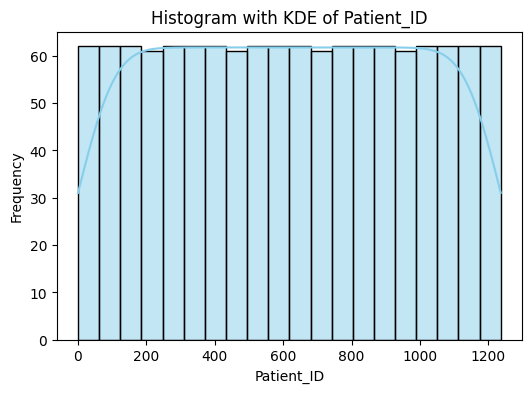

Age 0.001285212939650411


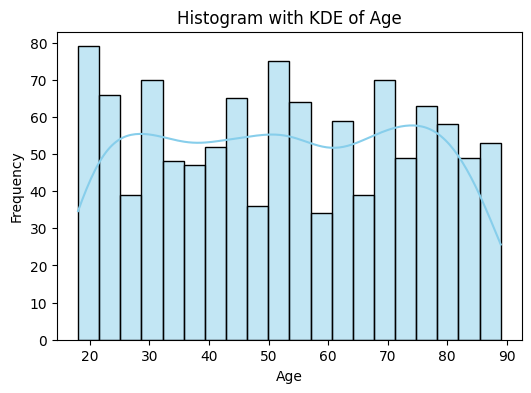

BMI 1.0009114473154077


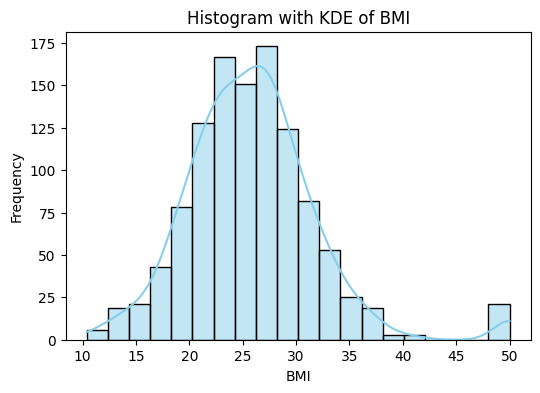

Blood_Pressure 0.2372977469675197


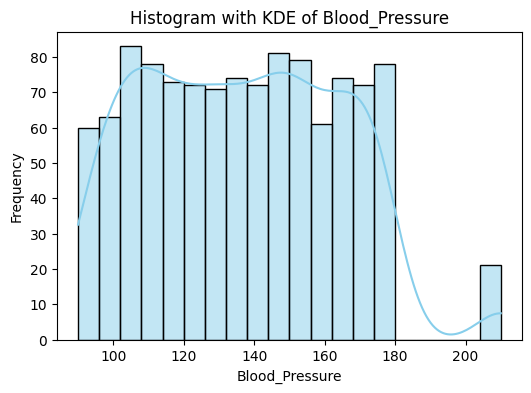

Cholesterol_Level -0.034418312512445856


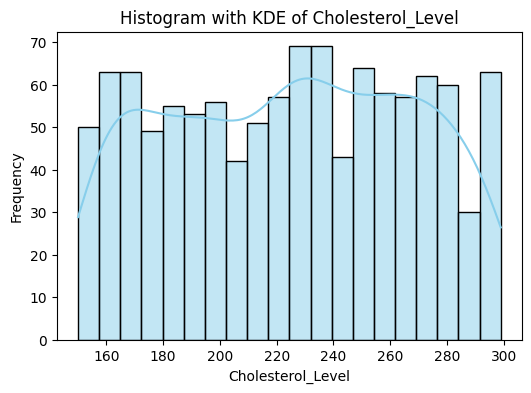

Glucose_Level 0.009538280803168627


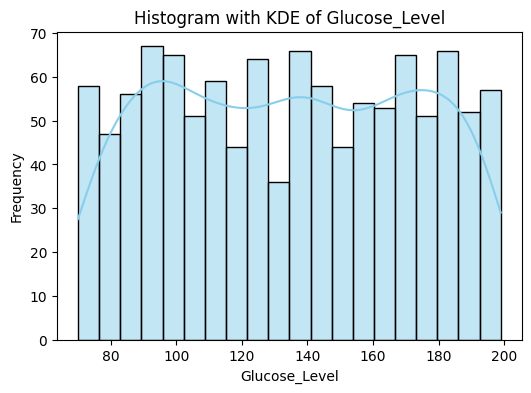

Disease_Risk_Score 0.17901300441573065


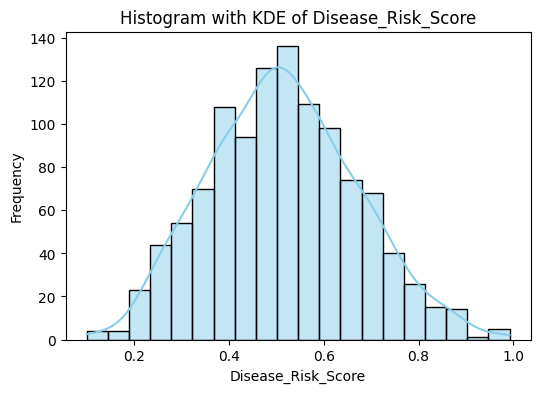

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    print(col, df[col].skew())
    plt.title(f'Histogram with KDE of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

In [ ]:
for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1747/1651664703.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,123
BMI,0
Blood_Pressure,0
Cholesterol_Level,0
Glucose_Level,0
Smoking_Status,128
Alcohol_Intake,525
Physical_Activity,125


In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: Gender
Gender
Male      385
Female    378
Other     350
Name: count, dtype: int64

Column: Smoking_Status
Smoking_Status
Yes    564
No     544
Name: count, dtype: int64

Column: Alcohol_Intake
Alcohol_Intake
High        373
Moderate    338
Name: count, dtype: int64

Column: Physical_Activity
Physical_Activity
Low       393
High      384
Medium    334
Name: count, dtype: int64

Column: Family_History
Family_History
No     584
Yes    526
Name: count, dtype: int64

Column: Stress_Level
Stress_Level
Medium    386
Low       371
High      356
Name: count, dtype: int64

Column: Existing_Conditions
Existing_Conditions
Malaria          203
Heart Disease    198
Diabetes         183
Tuberculosis     172
Hypertension     169
Name: count, dtype: int64

Column: Medication_Adherence
Medication_Adherence
Good       394
Average    378
Poor       338
Name: count, dtype: int64

Column: Risk_Category
Risk_Category
Medium    707
Low       264
High      141
Name: count, dtype: int64


In [ ]:
cat_cols = ['Gender', 'Smoking_Status', 'Alcohol_Intake',
            'Physical_Activity', 'Family_History',
            'Stress_Level', 'Existing_Conditions',
            'Medication_Adherence', 'Risk_Category']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
BMI,0
Blood_Pressure,0
Cholesterol_Level,0
Glucose_Level,0
Smoking_Status,0
Alcohol_Intake,0
Physical_Activity,0


In [ ]:
df['Age'] = df['Age'].astype(int)

In [ ]:
df.dtypes

,0
Patient_ID,int64
Age,int64
Gender,object
BMI,float64
Blood_Pressure,float64
Cholesterol_Level,float64
Glucose_Level,float64
Smoking_Status,object
Alcohol_Intake,object
Physical_Activity,object


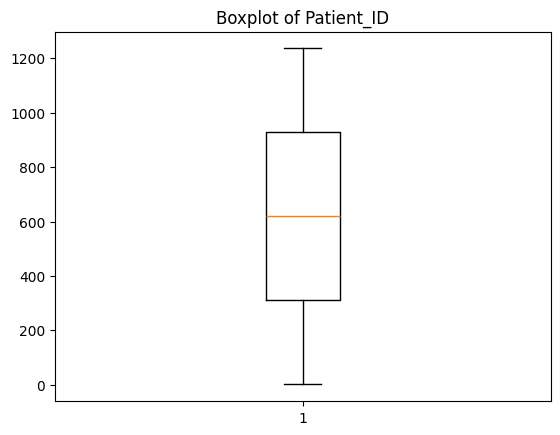

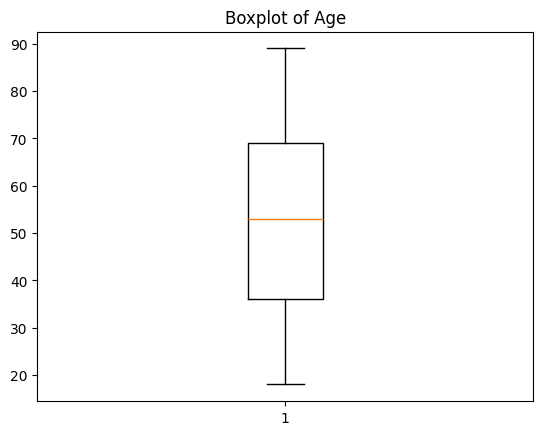

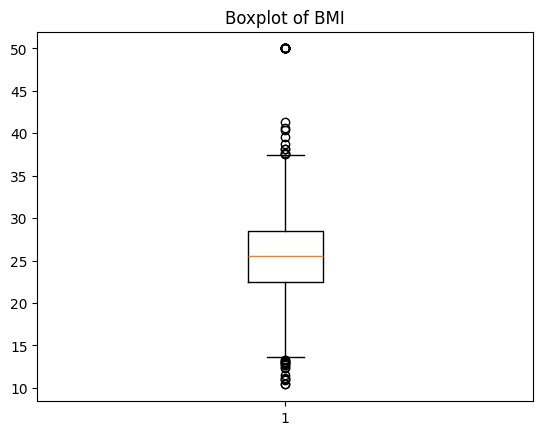

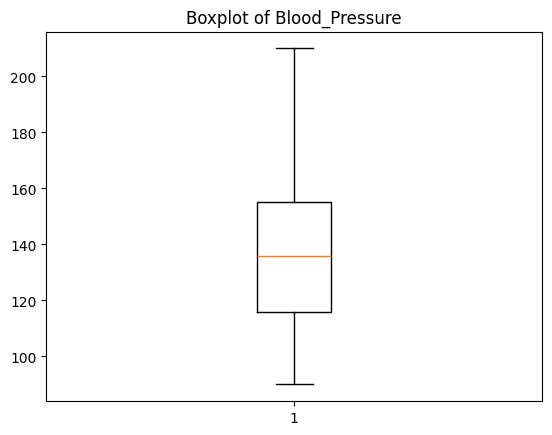

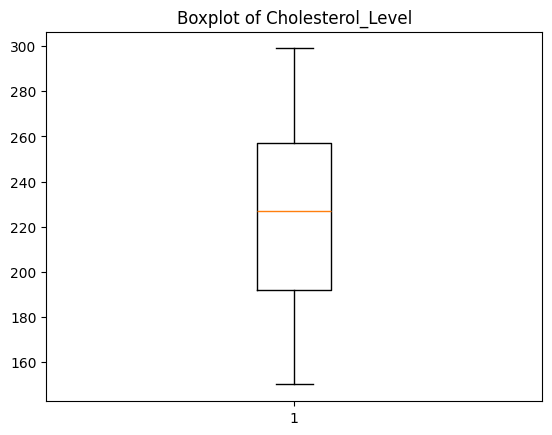

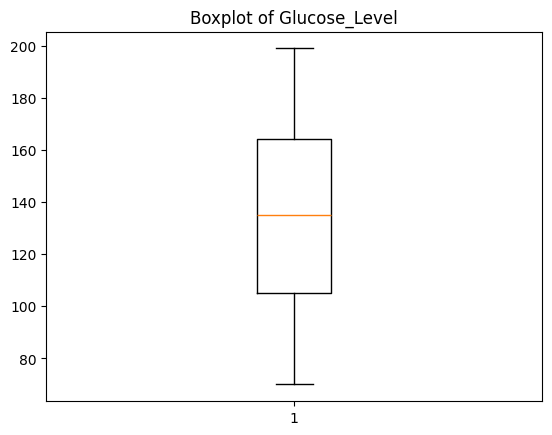

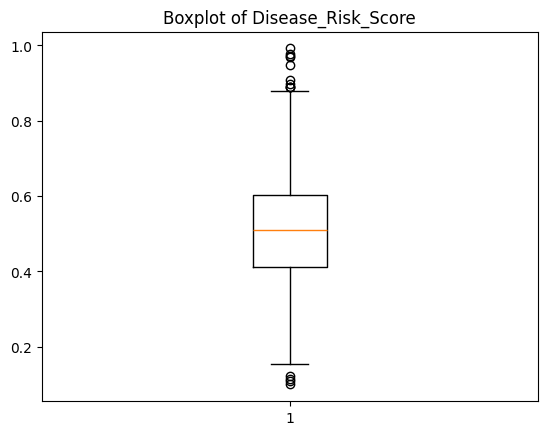

In [ ]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_columns:
    plt.figure()
    plt.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
for col in numeric_columns:

    Q1 = df[numeric_columns].quantile(0.25)
    Q3 = df[numeric_columns].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping using np.where
    df[numeric_columns] = np.where(df[numeric_columns] > upper_bound, upper_bound,
                np.where(df[numeric_columns] < lower_bound, lower_bound, df[numeric_columns]))

print("Capping done for all columns!")

Capping done for all columns!


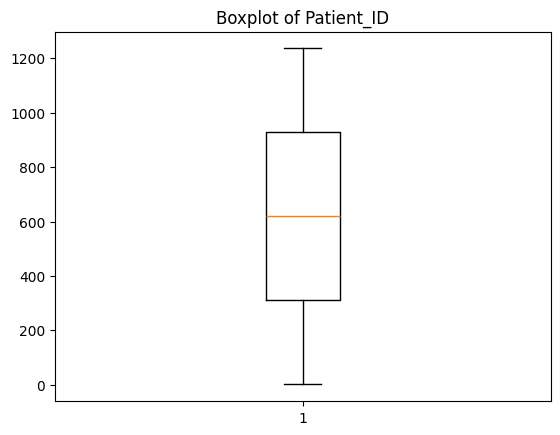

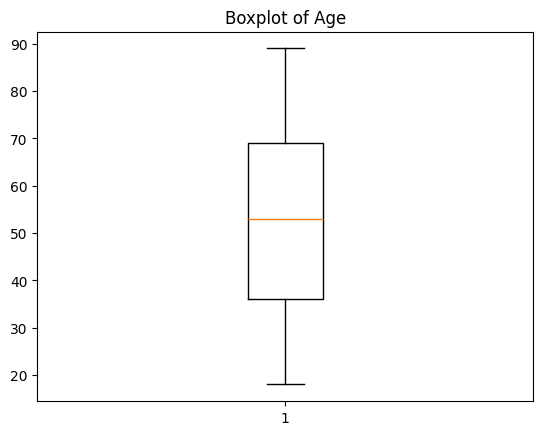

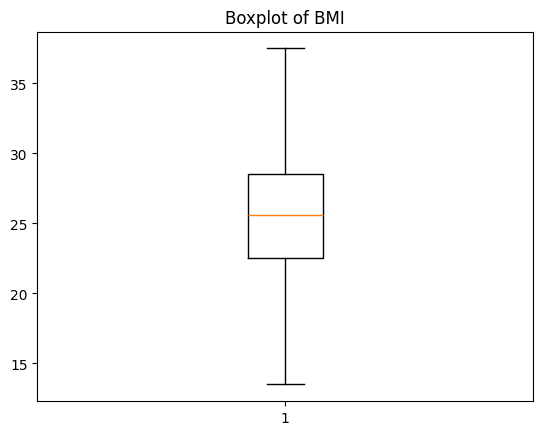

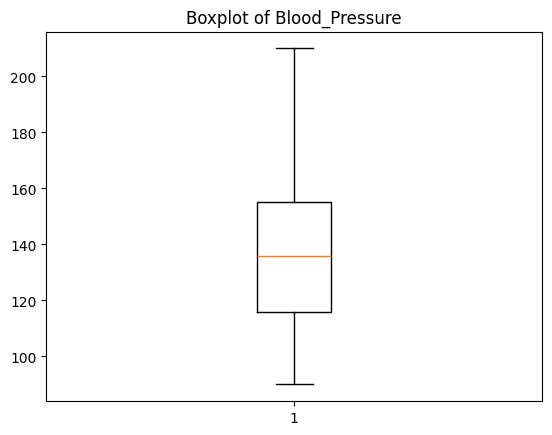

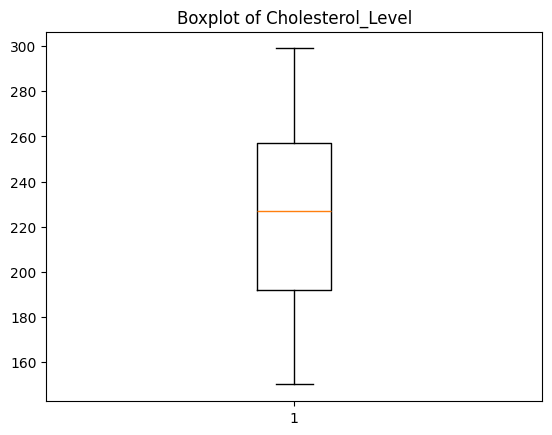

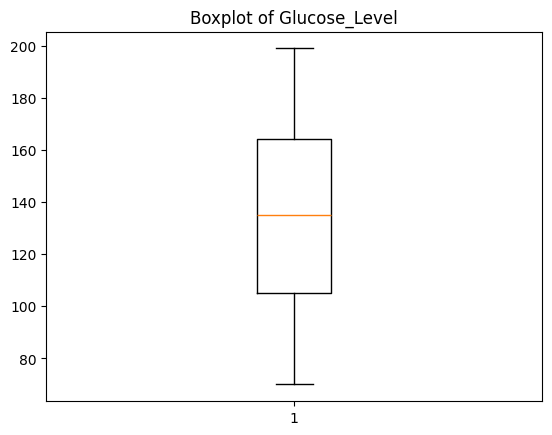

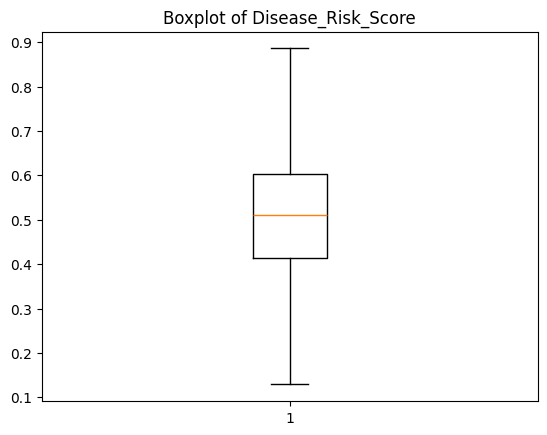

In [ ]:
for col in numeric_columns:
    plt.figure()
    plt.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
cat_cols

['Gender',
 'Smoking_Status',
 'Alcohol_Intake',
 'Physical_Activity',
 'Family_History',
 'Stress_Level',
 'Existing_Conditions',
 'Medication_Adherence',
 'Risk_Category']

In [ ]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

In [ ]:
df['Smoking_Status'] = df['Smoking_Status'].map({'Yes': 1, 'No': 0})

In [ ]:
df['Alcohol_Intake'] = df['Alcohol_Intake'].map({'High': 1, 'Moderate': 0})

In [ ]:
df['Physical_Activity'] = df['Physical_Activity'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [ ]:
df['Family_History'] = df['Family_History'].map({'Yes': 1, 'No': 0})

In [ ]:
df['Stress_Level'] = df['Stress_Level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [ ]:
df = pd.get_dummies(df, columns=['Existing_Conditions'], drop_first=True)

In [ ]:
df['Medication_Adherence'] = df['Medication_Adherence'].map({
    'Poor': 0,
    'Average': 1,
    'Good': 2
})

In [ ]:
df['Risk_Category'] = df['Risk_Category'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [ ]:
df.head()

,Patient_ID,Age,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Alcohol_Intake,Physical_Activity,Family_History,Stress_Level,Medication_Adherence,Disease_Risk_Score,Risk_Category,Gender_Male,Gender_Other,Existing_Conditions_Heart Disease,Existing_Conditions_Hypertension,Existing_Conditions_Malaria,Existing_Conditions_Tuberculosis
0,1.0,69.0,33.6,210.0,242.0,103.0,1,1,2,0,0,1,0.455882,1,False,True,False,False,True,False
1,2.0,32.0,26.5,164.0,228.0,138.0,0,0,0,1,1,1,0.543097,1,True,False,False,False,True,False
2,3.0,53.0,25.6,148.0,259.0,124.0,1,1,0,1,0,1,0.538449,1,False,False,True,False,False,False
3,4.0,78.0,21.6,110.0,251.0,79.0,1,0,1,0,1,1,0.345532,0,False,False,False,False,True,False
4,5.0,38.0,19.0,143.0,255.0,111.0,1,1,1,0,1,2,0.511120,1,True,False,False,False,False,False


In [ ]:
df = df.drop('Patient_ID', axis=1)

In [ ]:
df['Age_Glucose'] = df['Age'] * df['Glucose_Level']
df['BP_Chol_Risk'] = df['Blood_Pressure'] * df['Cholesterol_Level']

{'whiskers': [<matplotlib.lines.Line2D at 0x7cd6722945f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7cd67228c920>,
 'boxes': [<matplotlib.lines.Line2D at 0x7cd672294950>],
 'medians': [<matplotlib.lines.Line2D at 0x7cd67228faa0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7cd67228f770>],
 'means': []}

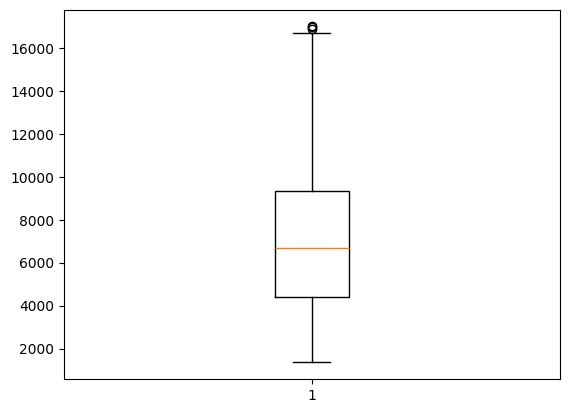

In [ ]:
plt.boxplot(df["Age_Glucose"])

{'whiskers': [<matplotlib.lines.Line2D at 0x7cd6720e5fd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7cd6720e6540>,
 'boxes': [<matplotlib.lines.Line2D at 0x7cd6720e5df0>],
 'medians': [<matplotlib.lines.Line2D at 0x7cd6720e7620>],
 'fliers': [<matplotlib.lines.Line2D at 0x7cd6720e57f0>],
 'means': []}

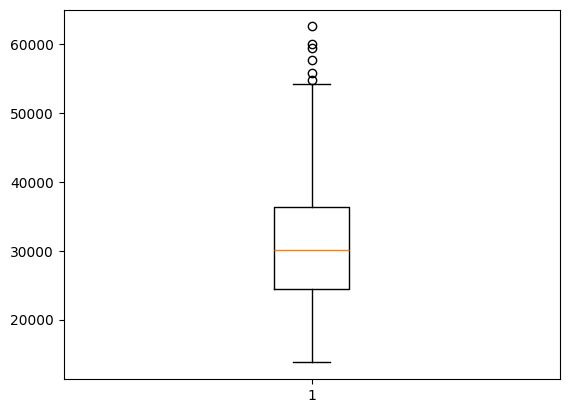

In [ ]:
plt.boxplot(df["BP_Chol_Risk"])

In [ ]:
fea_out = ['BP_Chol_Risk', 'Age_Glucose']

In [ ]:
for col in fea_out:

    Q1 = df[fea_out].quantile(0.25)
    Q3 = df[fea_out].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping using np.where
    df[fea_out] = np.where(df[fea_out] > upper_bound, upper_bound,
                np.where(df[fea_out] < lower_bound, lower_bound, df[fea_out]))

print("Capping done for all columns!")

Capping done for all columns!


In [ ]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Alcohol_Intake,Physical_Activity,Family_History,Stress_Level,...,Disease_Risk_Score,Risk_Category,Gender_Male,Gender_Other,Existing_Conditions_Heart Disease,Existing_Conditions_Hypertension,Existing_Conditions_Malaria,Existing_Conditions_Tuberculosis,Age_Glucose,BP_Chol_Risk
0,69.0,33.6,210.0,242.0,103.0,1,1,2,0,0,...,0.455882,1,False,True,False,False,True,False,7107.0,50820.0
1,32.0,26.5,164.0,228.0,138.0,0,0,0,1,1,...,0.543097,1,True,False,False,False,True,False,4416.0,37392.0
2,53.0,25.6,148.0,259.0,124.0,1,1,0,1,0,...,0.538449,1,False,False,True,False,False,False,6572.0,38332.0
3,78.0,21.6,110.0,251.0,79.0,1,0,1,0,1,...,0.345532,0,False,False,False,False,True,False,6162.0,27610.0
4,38.0,19.0,143.0,255.0,111.0,1,1,1,0,1,...,0.511120,1,True,False,False,False,False,False,4218.0,36465.0


In [ ]:
df.dtypes

,0
Age,float64
BMI,float64
Blood_Pressure,float64
Cholesterol_Level,float64
Glucose_Level,float64
Smoking_Status,int64
Alcohol_Intake,int64
Physical_Activity,int64
Family_History,int64
Stress_Level,int64


Discover Insights

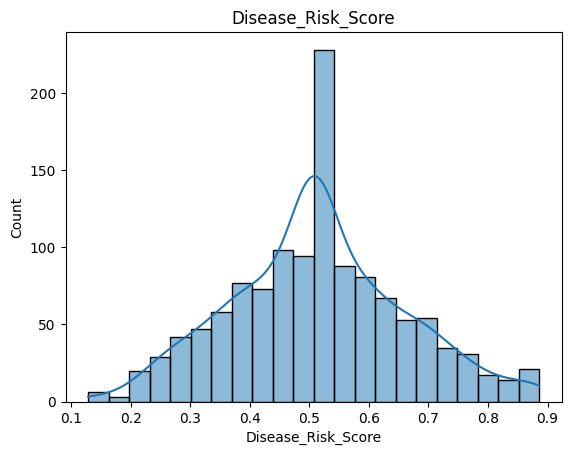

In [ ]:
sns.histplot(df['Disease_Risk_Score'], kde=True)
plt.title("Disease_Risk_Score")
plt.show()

This histogram shows the distribution of the disease risk score. Most values are concentrated around 0.5, indicating that the majority of individuals have a moderate risk. The data follows a normal distribution pattern, with fewer individuals at extreme low and high risk levels. The KDE curve confirms this smooth bell-shaped distribution

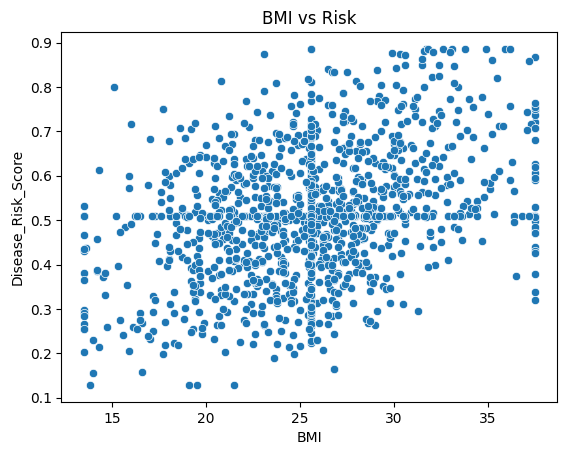

In [ ]:
sns.scatterplot(x='BMI', y='Disease_Risk_Score', data=df)
plt.title("BMI vs Risk")
plt.show()

This scatter plot shows the relationship between BMI and disease risk score. There is a moderate positive correlation, indicating that individuals with higher BMI tend to have higher disease risk. However, the spread of points suggests that BMI alone is not sufficient to predict risk, and other features also contribute to the outcome

In [ ]:
correlation = df['BMI'].corr(df['Disease_Risk_Score'])
print(f"Correlation between BMI and Disease_Risk_Score: {correlation}")

Correlation between BMI and Disease_Risk_Score: 0.37095766366711397


The correlation between BMI and disease risk score is approximately 0.37, which indicates a moderate positive relationship. This means that higher BMI is associated with higher disease risk, but BMI alone is not a strong predictor, and other features also influence the outcome

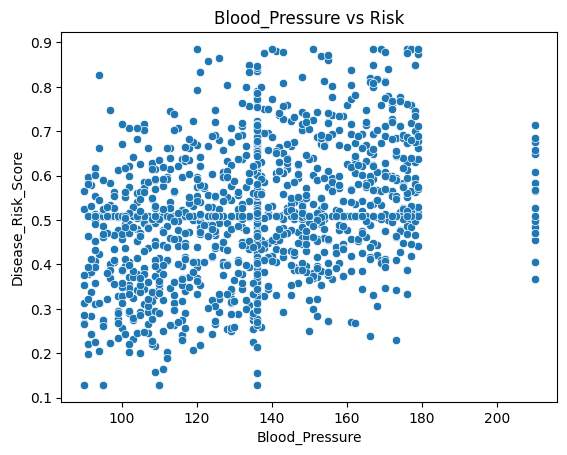

In [ ]:
sns.scatterplot(x='Blood_Pressure', y='Disease_Risk_Score', data=df)
plt.title("Blood_Pressure vs Risk")
plt.show()

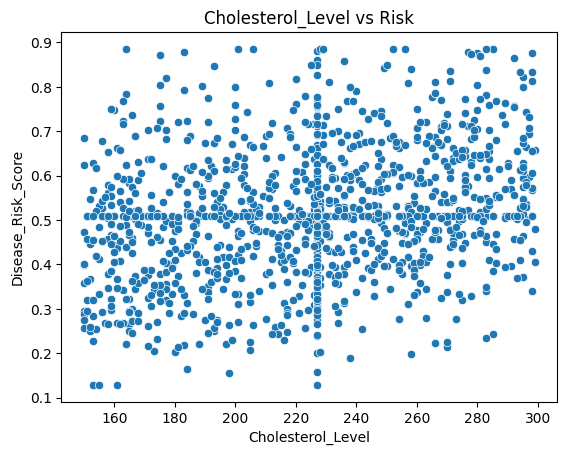

In [ ]:
sns.scatterplot(x='Cholesterol_Level', y='Disease_Risk_Score', data=df)
plt.title("Cholesterol_Level vs Risk")
plt.show()

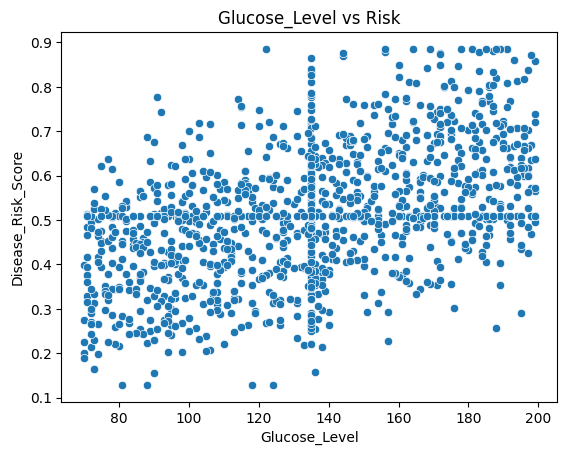

In [ ]:
sns.scatterplot(x='Glucose_Level', y='Disease_Risk_Score', data=df)
plt.title("Glucose_Level vs Risk")
plt.show()

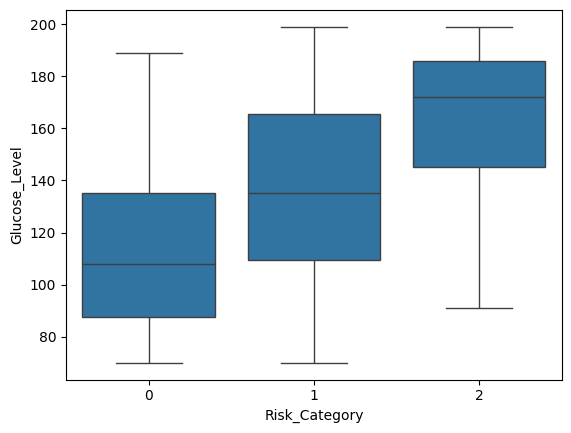

In [ ]:
sns.boxplot(x='Risk_Category', y='Glucose_Level', data=df)
plt.show()

This box plot shows the distribution of glucose levels across different risk categories. There is a clear upward trend, where higher risk categories have higher median glucose levels. This indicates that glucose is a strong contributing factor in determining disease risk

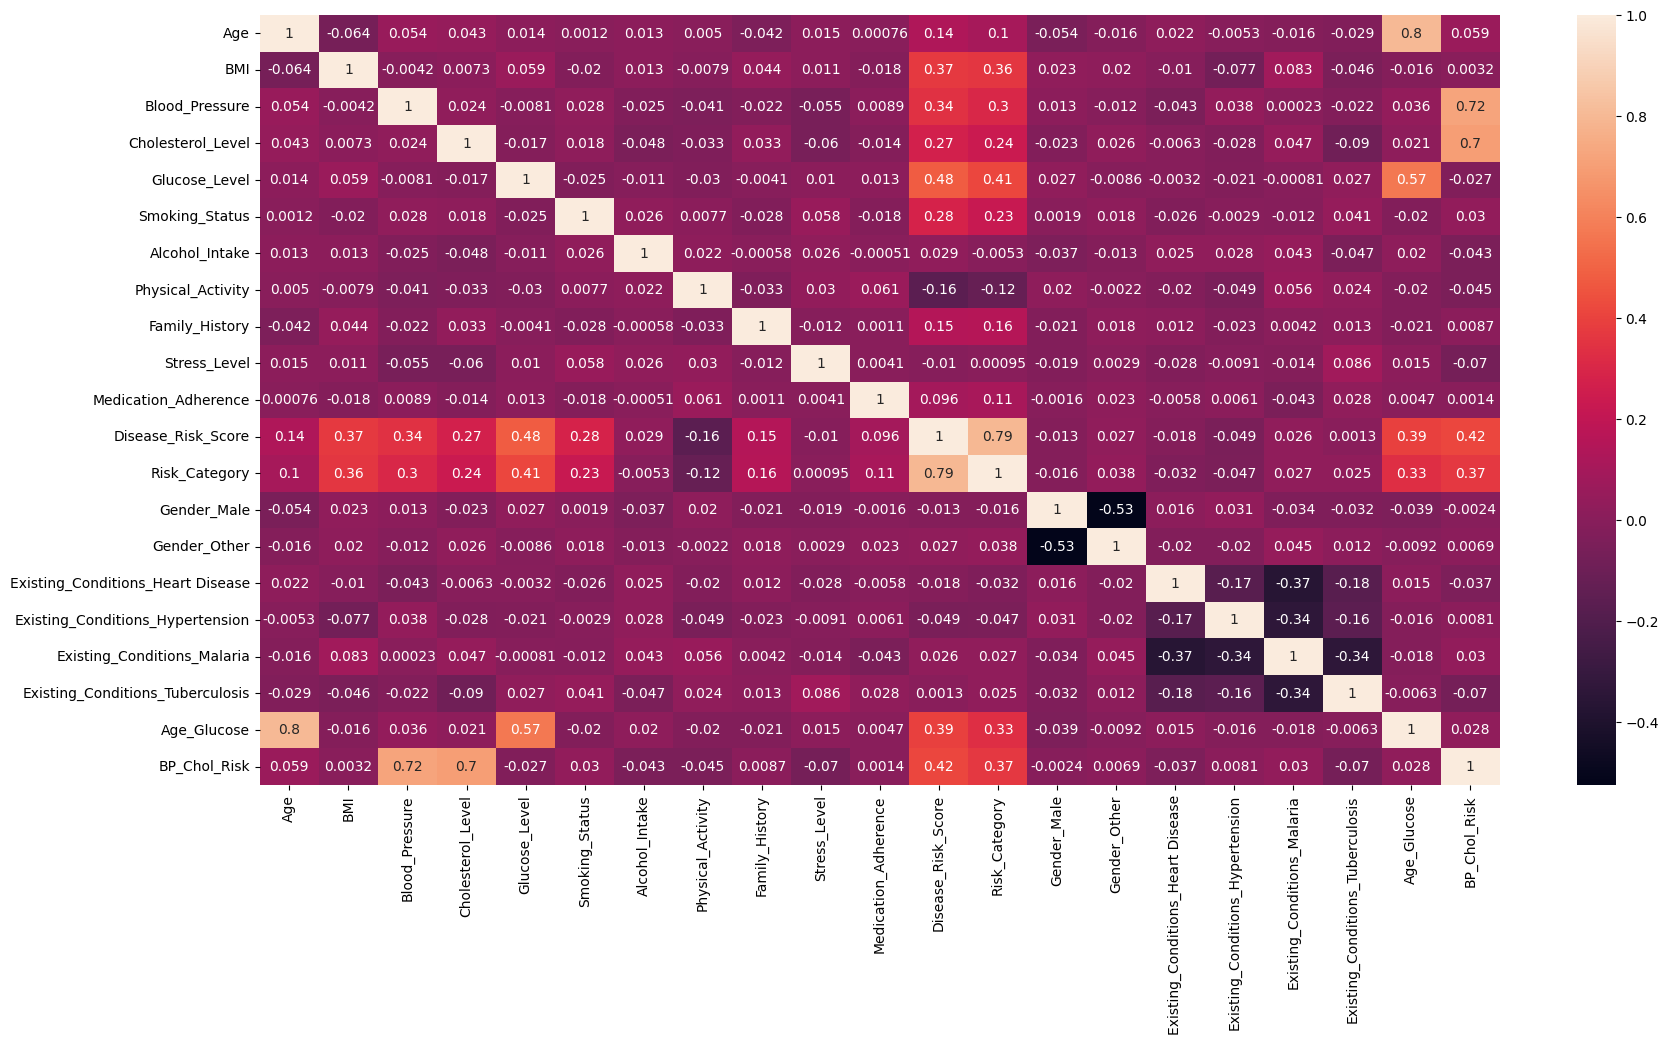

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

This correlation heatmap shows the relationships between all features in the dataset. The most influential features for disease risk are glucose level, BMI, blood pressure, and cholesterol, all showing positive correlations. Physical activity has a negative correlation, indicating it reduces risk. This analysis helps in feature selection and improving model performance.

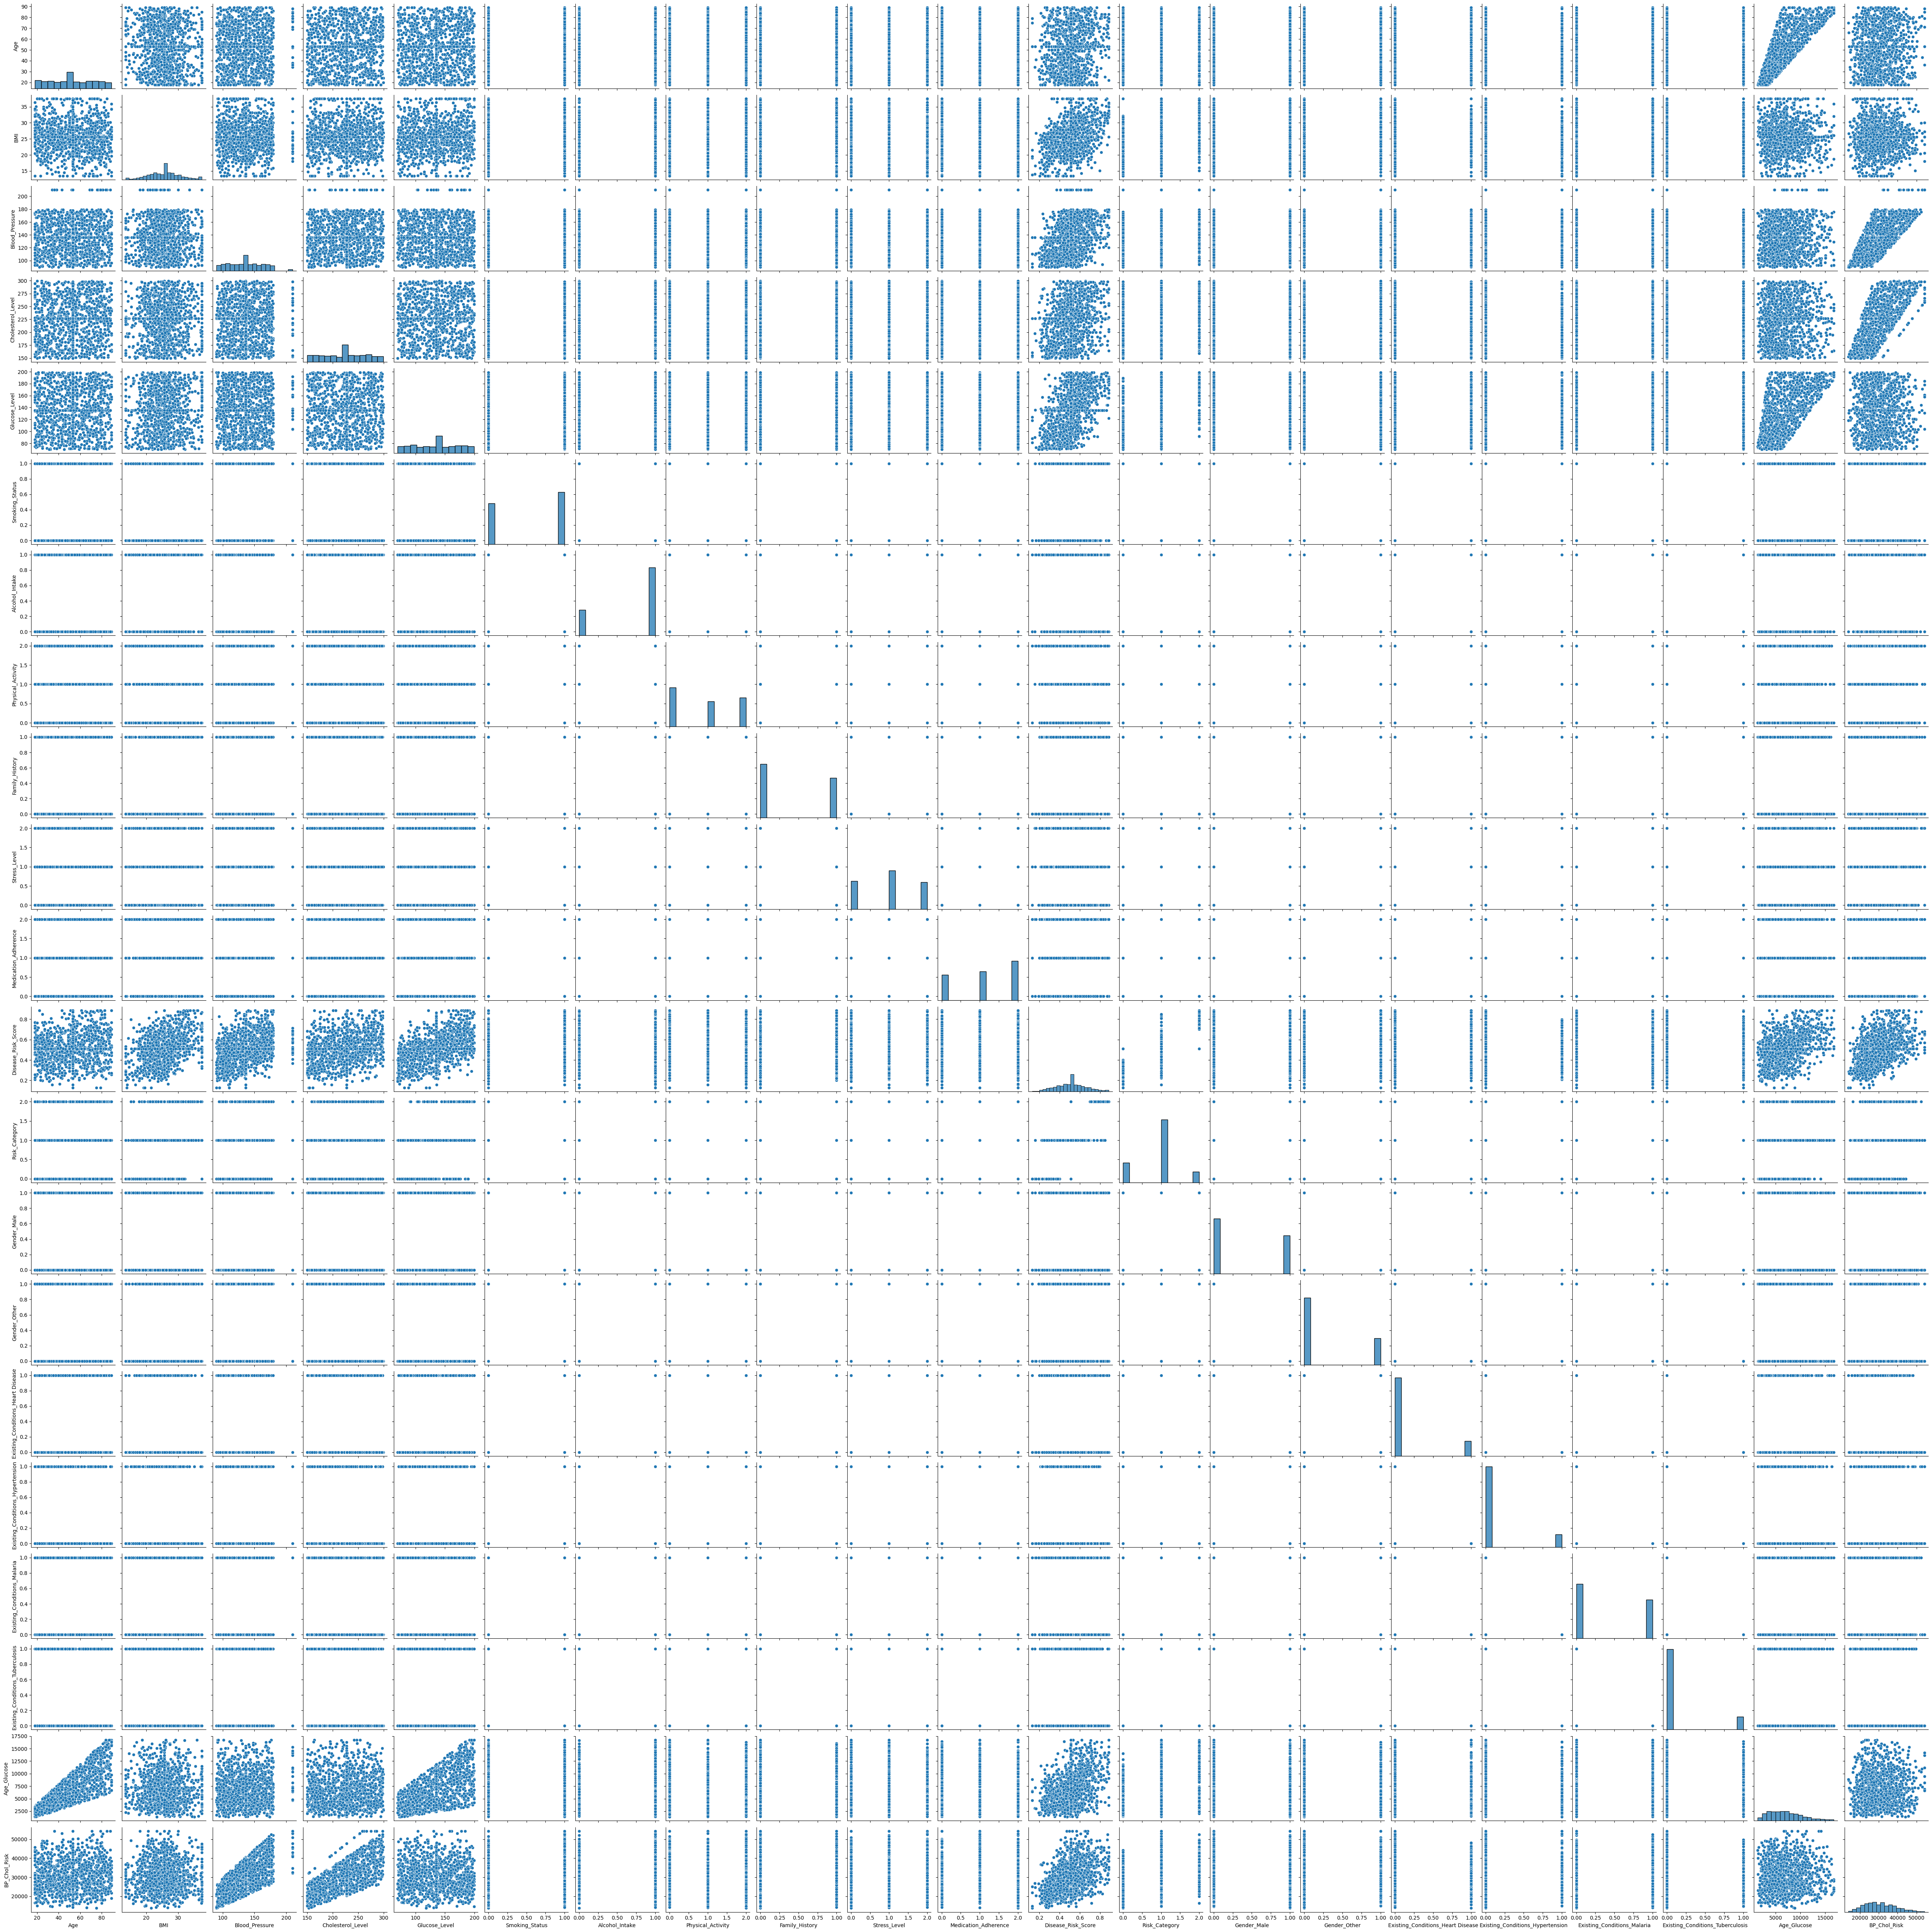

In [ ]:
sns.pairplot(df)
plt.show()

This pair plot visualizes relationships between all features in the dataset. The diagonal shows feature distributions, while off-diagonal plots show pairwise relationships. We can observe positive trends between variables like BMI and disease risk, while some features show weak or no correlation. The presence of discrete lines indicates categorical variables.

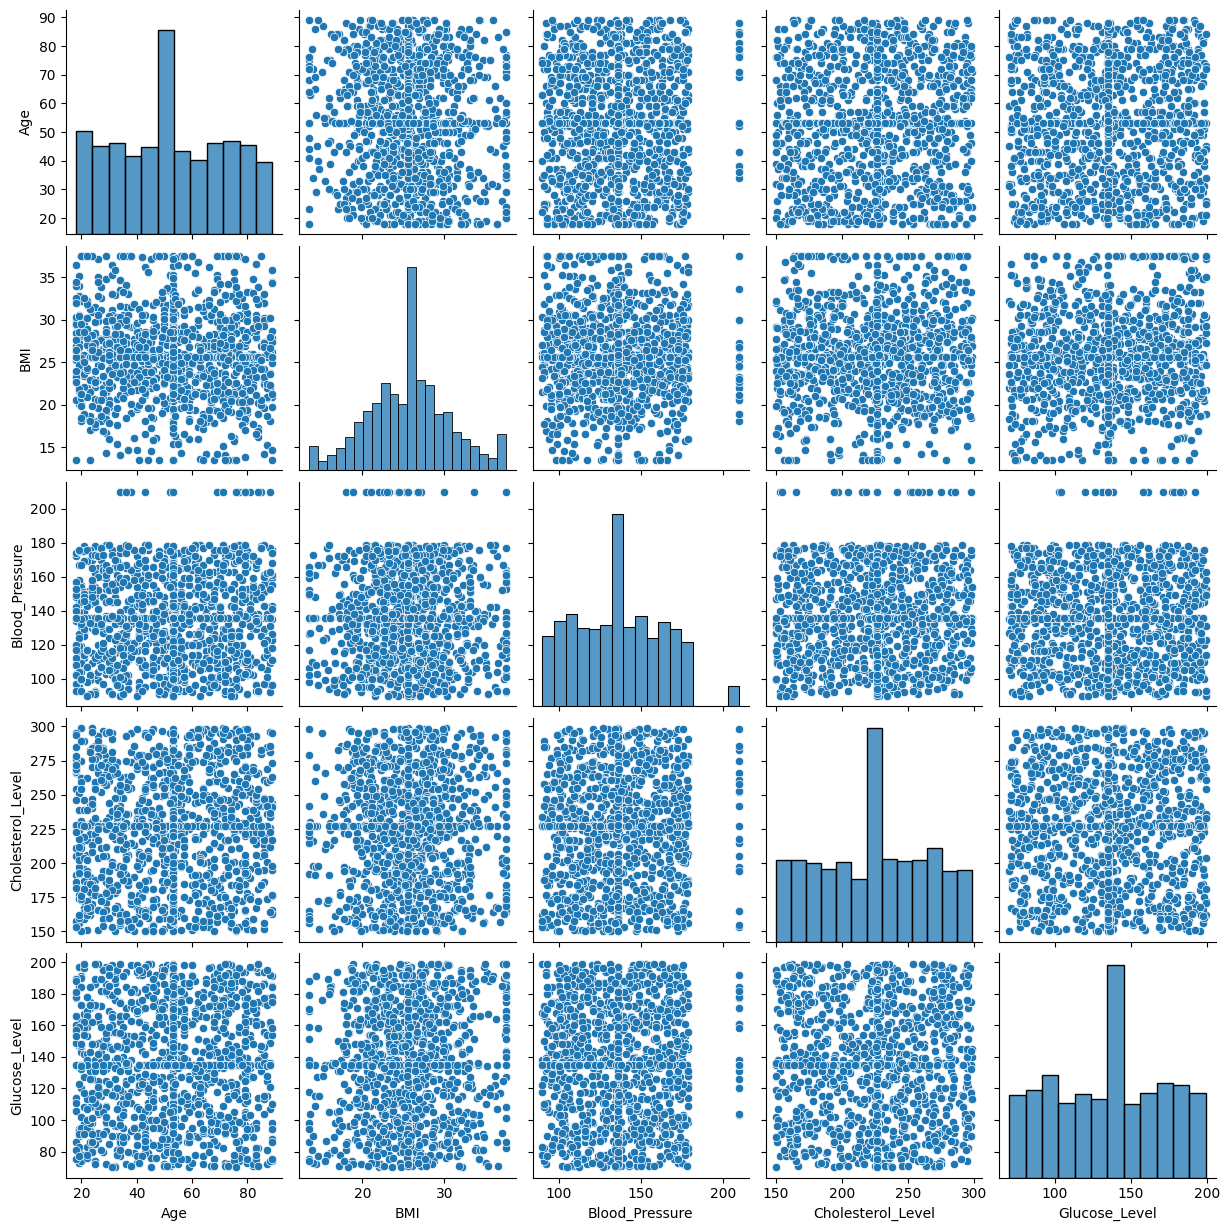

In [ ]:
cols = ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'Glucose_Level']
sns.pairplot(df[cols])
plt.show()

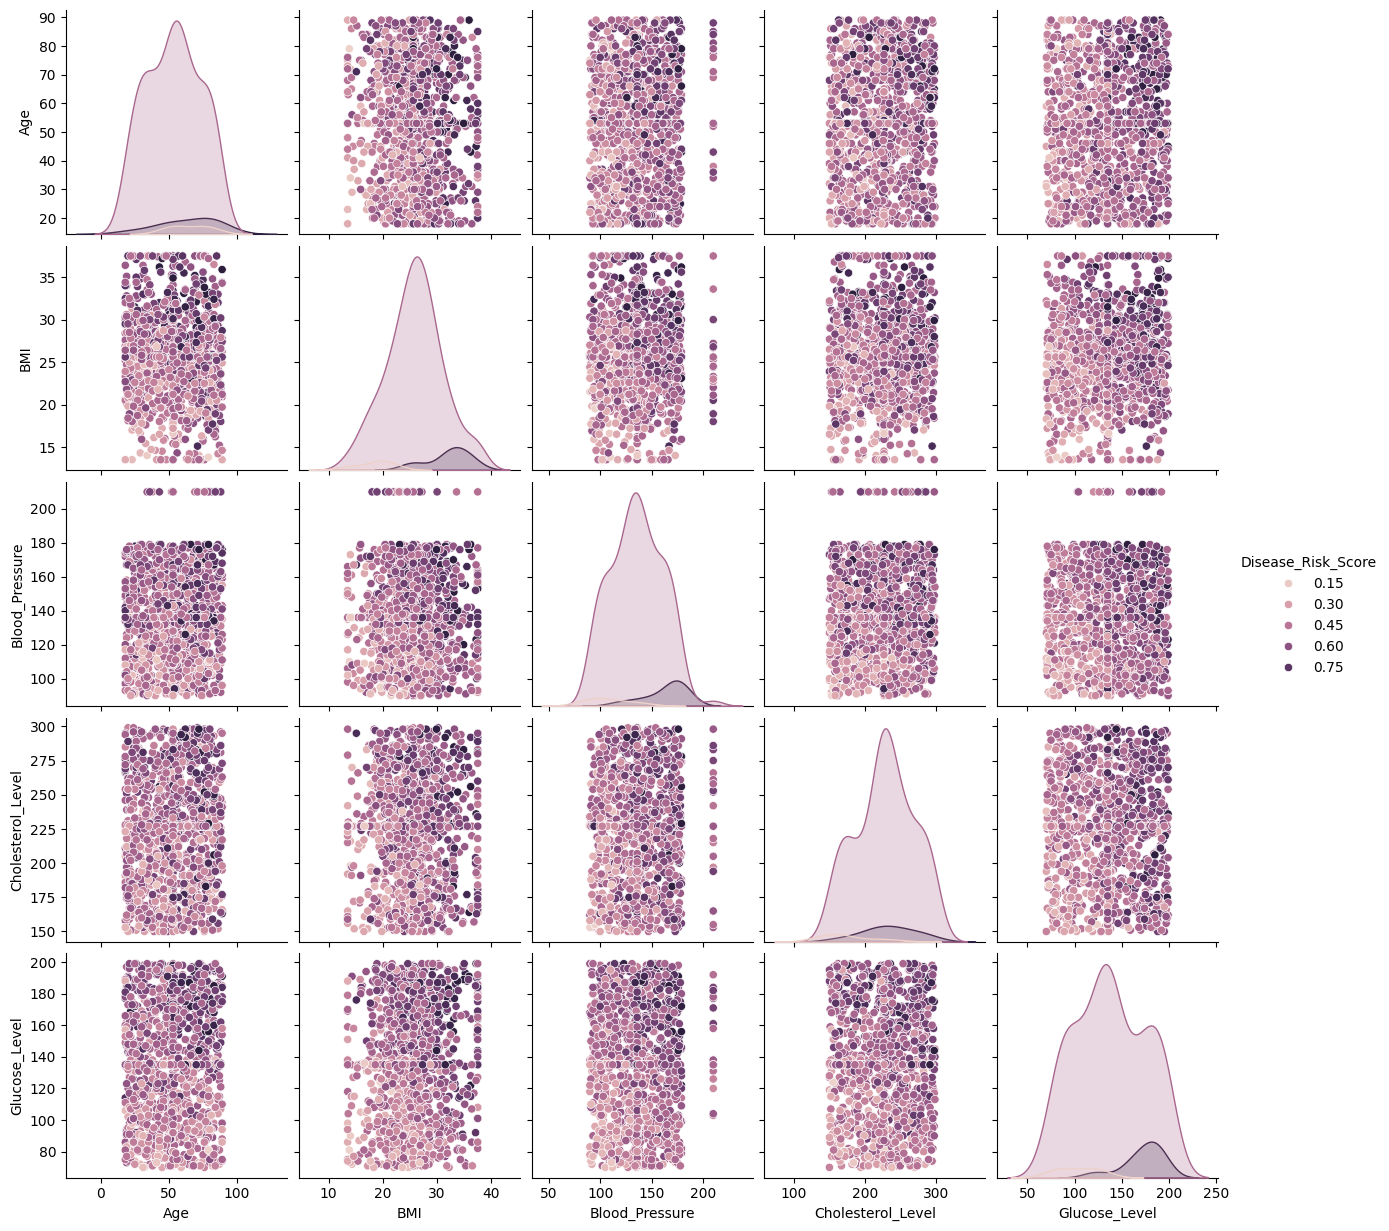

In [ ]:
cols = ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'Glucose_Level']
sns.pairplot(df, vars=cols, hue='Disease_Risk_Score', diag_kind='kde')
plt.show()

In [ ]:
df['Age'] = df['Age'].astype(int)

In [ ]:
df.dtypes

,0
Age,int64
BMI,float64
Blood_Pressure,float64
Cholesterol_Level,float64
Glucose_Level,float64
Smoking_Status,int64
Alcohol_Intake,int64
Physical_Activity,int64
Family_History,int64
Stress_Level,int64


In [ ]:
df.isnull().sum()

,0
Age,0
BMI,0
Blood_Pressure,0
Cholesterol_Level,0
Glucose_Level,0
Smoking_Status,0
Alcohol_Intake,0
Physical_Activity,0
Family_History,0
Stress_Level,0


In [ ]:
df.to_csv("clean_healthcare_data.csv" , index = False)

In [ ]:
# df = pd.read_csv("/content/clean_healthcare_data.csv")

In [ ]:
df.sample(10)

,Age,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Alcohol_Intake,Physical_Activity,Family_History,Stress_Level,...,Disease_Risk_Score,Risk_Category,Gender_Male,Gender_Other,Existing_Conditions_Heart Disease,Existing_Conditions_Hypertension,Existing_Conditions_Malaria,Existing_Conditions_Tuberculosis,Age_Glucose,BP_Chol_Risk
879,64,25.6,136.0,250.0,119.0,1,0,2,1,1,...,0.572196,1,False,False,False,False,False,False,7616.0,34000.0
268,34,21.1,210.0,227.0,138.0,1,0,2,0,2,...,0.566370,1,False,True,False,True,False,False,4692.0,47670.0
1184,72,29.9,176.0,298.0,144.0,1,1,2,0,2,...,0.875698,2,False,False,False,False,True,False,10368.0,52448.0
495,34,25.6,119.0,242.0,110.0,0,0,0,1,1,...,0.544256,1,False,True,True,False,False,False,3740.0,28798.0
285,53,25.6,117.0,265.0,162.0,1,1,1,0,2,...,0.663825,1,False,False,False,True,False,False,8586.0,31005.0
310,53,25.6,174.0,219.0,94.0,1,0,2,0,0,...,0.509558,1,True,False,False,False,False,False,4982.0,38106.0
227,42,24.2,137.0,175.0,144.0,1,0,1,1,0,...,0.454982,1,True,False,False,False,True,False,6048.0,23975.0
1113,53,25.6,102.0,223.0,154.0,0,1,2,0,2,...,0.491895,1,False,True,False,False,False,True,8162.0,22746.0
728,23,25.6,176.0,185.0,184.0,1,1,2,0,2,...,0.612940,1,True,False,False,False,False,True,4232.0,32560.0
322,42,37.4,125.0,164.0,154.0,0,1,2,1,1,...,0.509558,1,True,False,False,False,True,False,6468.0,20500.0


In [ ]:
df.isnull().sum()

,0
Age,0
BMI,0
Blood_Pressure,0
Cholesterol_Level,0
Glucose_Level,0
Smoking_Status,0
Alcohol_Intake,0
Physical_Activity,0
Family_History,0
Stress_Level,0


In [ ]:
df.columns

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'Glucose_Level',
       'Smoking_Status', 'Alcohol_Intake', 'Physical_Activity',
       'Family_History', 'Stress_Level', 'Medication_Adherence',
       'Disease_Risk_Score', 'Risk_Category', 'Gender_Male', 'Gender_Other',
       'Existing_Conditions_Heart Disease', 'Existing_Conditions_Hypertension',
       'Existing_Conditions_Malaria', 'Existing_Conditions_Tuberculosis',
       'Age_Glucose', 'BP_Chol_Risk'],
      dtype='object')

# Model

In [ ]:
scaler = StandardScaler()

In [ ]:
X = df.drop('Disease_Risk_Score', axis=1)
y = df['Disease_Risk_Score']

In [ ]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Alcohol_Intake,Physical_Activity,Family_History,Stress_Level,...,Disease_Risk_Score,Risk_Category,Gender_Male,Gender_Other,Existing_Conditions_Heart Disease,Existing_Conditions_Hypertension,Existing_Conditions_Malaria,Existing_Conditions_Tuberculosis,Age_Glucose,BP_Chol_Risk
0,69,33.6,210.0,242.0,103.0,1,1,2,0,0,...,0.455882,1,False,True,False,False,True,False,7107.0,50820.0
1,32,26.5,164.0,228.0,138.0,0,0,0,1,1,...,0.543097,1,True,False,False,False,True,False,4416.0,37392.0
2,53,25.6,148.0,259.0,124.0,1,1,0,1,0,...,0.538449,1,False,False,True,False,False,False,6572.0,38332.0
3,78,21.6,110.0,251.0,79.0,1,0,1,0,1,...,0.345532,0,False,False,False,False,True,False,6162.0,27610.0
4,38,19.0,143.0,255.0,111.0,1,1,1,0,1,...,0.511120,1,True,False,False,False,False,False,4218.0,36465.0


In [ ]:
X.head()

,Age,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Alcohol_Intake,Physical_Activity,Family_History,Stress_Level,Medication_Adherence,Risk_Category,Gender_Male,Gender_Other,Existing_Conditions_Heart Disease,Existing_Conditions_Hypertension,Existing_Conditions_Malaria,Existing_Conditions_Tuberculosis,Age_Glucose,BP_Chol_Risk
0,69,33.6,210.0,242.0,103.0,1,1,2,0,0,1,1,False,True,False,False,True,False,7107.0,50820.0
1,32,26.5,164.0,228.0,138.0,0,0,0,1,1,1,1,True,False,False,False,True,False,4416.0,37392.0
2,53,25.6,148.0,259.0,124.0,1,1,0,1,0,1,1,False,False,True,False,False,False,6572.0,38332.0
3,78,21.6,110.0,251.0,79.0,1,0,1,0,1,1,0,False,False,False,False,True,False,6162.0,27610.0
4,38,19.0,143.0,255.0,111.0,1,1,1,0,1,2,1,True,False,False,False,False,False,4218.0,36465.0


In [ ]:
y.head()

,Disease_Risk_Score
0,0.455882
1,0.543097
2,0.538449
3,0.345532
4,0.511120


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test)  # predicted risk scores
print(y_pred_lr)

[0.43986471 0.32404172 0.32121219 0.78279437 0.24349806 0.52473476
 0.52023326 0.38719091 0.58895277 0.51223394 0.57458309 0.21970862
 0.62983471 0.53285018 0.70604057 0.6625892  0.46045465 0.61790651
 0.52721169 0.81951885 0.70839433 0.55251335 0.5360506  0.81477358
 0.52724312 0.61977076 0.42931219 0.7391273  0.45742459 0.52551195
 0.55095413 0.49274146 0.59609138 0.56066749 0.32474609 0.59434437
 0.59860429 0.56627764 0.70365339 0.54047132 0.52109369 0.53561701
 0.48636361 0.5187593  0.35894162 0.32893237 0.50071243 0.31080702
 0.71539125 0.23777161 0.47857385 0.3079083  0.65778437 0.37565828
 0.33438847 0.48001465 0.76068749 0.56122828 0.31853155 0.40487394
 0.64989841 0.29446749 0.54571904 0.59531269 0.23175093 0.39481888
 0.53658732 0.32377007 0.34310954 0.40845959 0.55260341 0.50980521
 0.35439701 0.66213145 0.49067317 0.58881658 0.65778437 0.32754511
 0.56913354 0.55877338 0.4996662  0.80460941 0.55772596 0.79116999
 0.38988549 0.68604348 0.39469676 0.54960623 0.55647523 0.3017

In [ ]:
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression MSE: 0.005646344834139209
Linear Regression R2: 0.7643321804671406


In [ ]:
print("Linear Regression MAE:",mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression RMSE:",np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression MAE: 0.056067258928268096
Linear Regression RMSE: 0.07514216415661189


In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge R2: 0.76401760098152
Ridge RMSE: 0.07519229891905324


In [ ]:
scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
print("CV Mean:", scores.mean())

CV Mean: 0.7552306758278173


In [ ]:
importance = lr.coef_
print(importance)

[-1.02369941e-02  3.24762780e-02  2.98860400e-02  2.34321478e-02
  2.71886889e-02  2.96777026e-02  6.57822274e-03 -1.23444250e-02
  1.20404714e-02 -8.66840049e-04  1.04737060e-02  5.60187758e-02
 -1.91813753e-03 -8.57560288e-04  1.67260810e-03 -1.28856697e-03
 -8.74326283e-05  1.65097147e-03  3.04732156e-02  7.99560577e-04]


This gives coefficients of Linear Regression model

Each number = weight of a feature

In [ ]:
features = X.columns
print(features)

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'Glucose_Level',
       'Smoking_Status', 'Alcohol_Intake', 'Physical_Activity',
       'Family_History', 'Stress_Level', 'Medication_Adherence',
       'Risk_Category', 'Gender_Male', 'Gender_Other',
       'Existing_Conditions_Heart Disease', 'Existing_Conditions_Hypertension',
       'Existing_Conditions_Malaria', 'Existing_Conditions_Tuberculosis',
       'Age_Glucose', 'BP_Chol_Risk'],
      dtype='object')


                              Feature  Importance
11                      Risk_Category    0.056019
1                                 BMI    0.032476
18                        Age_Glucose    0.030473
2                      Blood_Pressure    0.029886
5                      Smoking_Status    0.029678
4                       Glucose_Level    0.027189
3                   Cholesterol_Level    0.023432
8                      Family_History    0.012040
10               Medication_Adherence    0.010474
6                      Alcohol_Intake    0.006578
14  Existing_Conditions_Heart Disease    0.001673
17   Existing_Conditions_Tuberculosis    0.001651
19                       BP_Chol_Risk    0.000800
16        Existing_Conditions_Malaria   -0.000087
13                       Gender_Other   -0.000858
9                        Stress_Level   -0.000867
15   Existing_Conditions_Hypertension   -0.001289
12                        Gender_Male   -0.001918
0                                 Age   -0.010237


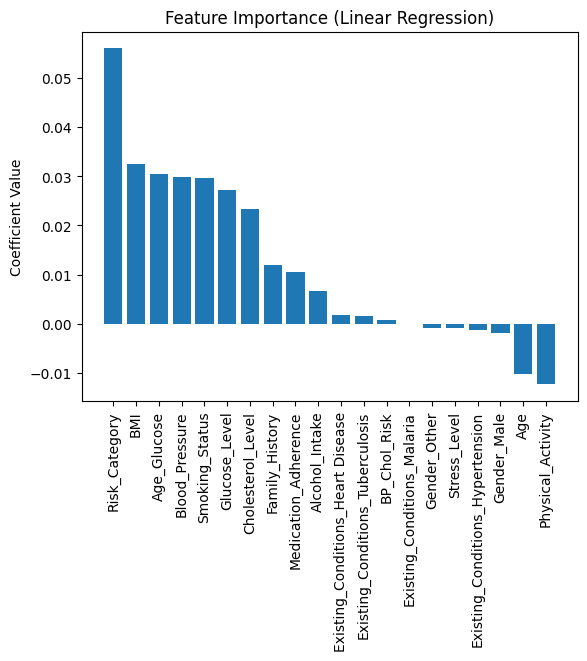

In [ ]:
# Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print(feat_imp)

# Plot
plt.figure()
plt.bar(feat_imp['Feature'], feat_imp['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance (Linear Regression)")
plt.ylabel("Coefficient Value")
plt.show()

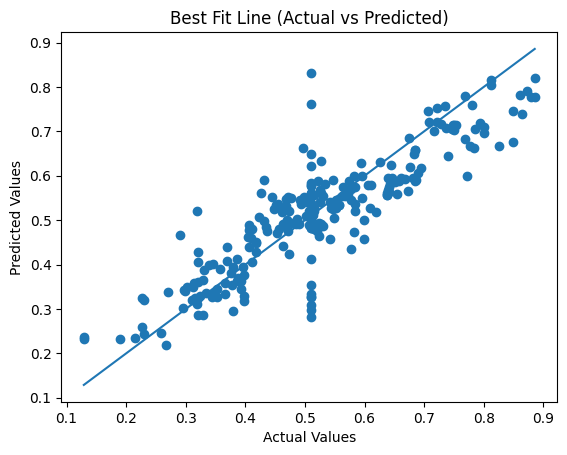

In [ ]:
# Predictions
y_pred = lr.predict(X_test)

# Plot
plt.figure()

plt.scatter(y_test, y_pred)   # actual vs predicted

# Best fit line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Best Fit Line (Actual vs Predicted)")

plt.show()

It shows how well your model is predicting.

Some points are scattered away -> Model is good but not perfect

This plot compares actual and predicted values. The diagonal line represents perfect predictions. Since most points are close to this line, the model performs well with low prediction error. Some deviations indicate minor errors, but overall the model captures the underlying relationship effectively

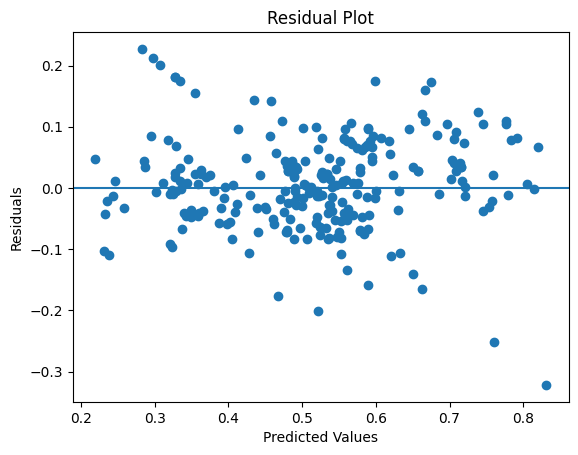

In [ ]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

**Actual value - Predicted value**

Residual = 0 → perfect prediction

Positive residual → model underestimated

Negative residual → model overestimated

The residual plot shows that residuals are randomly scattered around zero with no clear pattern, indicating that the model satisfies linearity and homoscedasticity assumptions. This suggests that the linear regression model is appropriate and performs well, although a few outliers are present.

In [ ]:
import pickle

pickle.dump(lr, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(X.columns, open('X_columns.pkl', 'wb'))

In [ ]:
lr = pickle.load(open('model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

import pickle
pickle.dump(pipeline, open('pipeline.pkl', 'wb'))
pickle.dump(X.columns, open('X_columns.pkl', 'wb'))

In [ ]:
import pandas as pd
import pickle

# Load the feature columns from the pickled file or use X.columns if not available
try:
    with open('X_columns.pkl', 'rb') as f:
        X_columns = pickle.load(f)
except FileNotFoundError:
    # Fallback if the pickle file is not found, use columns from X DataFrame
    X_columns = X.columns

# ---------------- USER INPUT ----------------
age = float(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
bp = float(input("Enter Blood Pressure: "))
chol = float(input("Enter Cholesterol: "))
gluc = float(input("Enter Glucose: "))

# ---------------- CREATE INPUT ----------------
user_dict = {
    'Age': age,
    'BMI': bmi,
    'Blood_Pressure': bp,
    'Cholesterol_Level': chol,
    'Glucose_Level': gluc
}

# Create a DataFrame with all the columns the model was trained on (X_columns)
# Initialize all values to 0 (for categorical features that are not provided by user input)
final_input_for_model = pd.DataFrame(0, index=[0], columns=X_columns)

# Overwrite the numerical columns in final_input_for_model with the user's input values
for col in user_dict.keys():
    if col in final_input_for_model.columns:
        final_input_for_model[col] = user_dict[col]

# Recreate engineered features for the input
final_input_for_model['Age_Glucose'] = final_input_for_model['Age'] * final_input_for_model['Glucose_Level']
final_input_for_model['BP_Chol_Risk'] = final_input_for_model['Blood_Pressure'] * final_input_for_model['Cholesterol_Level']

# ---------------- SCALE THE ENTIRE FINAL INPUT DF ----------------
# The scaler was fitted on the entire X_train, so it should transform the entire input.
final_input_for_model_scaled = scaler.transform(final_input_for_model)

# ---------------- PREDICT ----------------
# Predict using the scaled numpy array to avoid the UserWarning
prediction = lr.predict(final_input_for_model_scaled)[0]

# ---------------- OUTPUT ----------------
print("\n🩺 Predicted Risk Score:", round(prediction, 2))

if prediction < 0.3:
    print("Risk Level: Low")
elif prediction < 0.6:
    print("Risk Level: Medium")
else:
    print("Risk Level: High")


Enter Age: 25
Enter BMI: 20
Enter Blood Pressure: 120
Enter Cholesterol: 180
Enter Glucose: 100

🩺 Predicted Risk Score: 0.23
Risk Level: Low


# cluster

Cluster patients based on health patterns

Group patients who have similar health conditions into the same category without using labels

In [ ]:
df = pd.read_csv("/content/clean_healthcare_data.csv")

In [ ]:
df['Risk_Category'].value_counts()

,count
Risk_Category,
1,831
0,264
2,141


In [ ]:
df['Risk_Category'] = pd.qcut(
    df['Disease_Risk_Score'],
    q=3,
    labels=[0,1,2]
)

Splits data into equal-sized groups (quantiles)

qcut = equal distribution of data into categories

In [ ]:
df['Risk_Category'].value_counts()

,count
Risk_Category,
0,412
1,412
2,412


In [ ]:
df.groupby('Risk_Category')[['BMI','Glucose_Level','BP_Chol_Risk']].mean()

/tmp/ipykernel_1747/1192570318.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Risk_Category')[['BMI','Glucose_Level','BP_Chol_Risk']].mean()


,BMI,Glucose_Level,BP_Chol_Risk
Risk_Category,,,
0,23.607282,115.376214,26984.907767
1,25.819903,134.186893,30796.515170
2,27.403155,154.366505,34271.260922


In [ ]:
features_cluster = ['Blood_Pressure', 'BMI', 'Cholesterol_Level', 'Age_Glucose']
X = df[features_cluster]

In [ ]:
X_scaled = scaler.fit_transform(X)

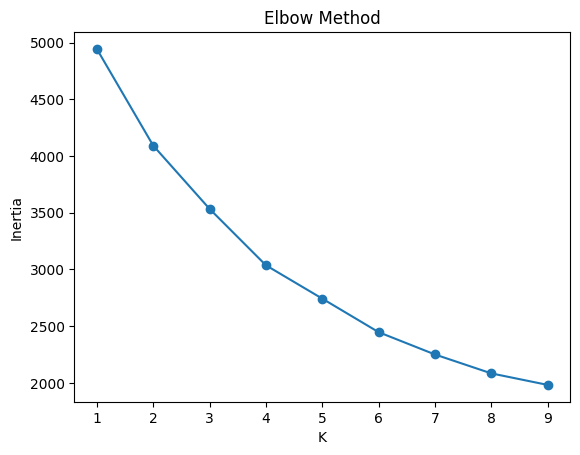

In [ ]:
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

Elbow Method graph used to find the best number of clusters (K) for K-Means clustering.The elbow method shows a sharp decrease in inertia up to K=3 or 4, after which the rate of decrease slows down. This indicates that the optimal number of clusters is around 3, as adding more clusters does not significantly improve clustering performance.

In [ ]:
# For K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42)
labels_3 = kmeans_3.fit_predict(X_scaled)

In [ ]:
# For K = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
labels_4 = kmeans_4.fit_predict(X_scaled)

In [ ]:
from sklearn.metrics import silhouette_score

print("K=3:", silhouette_score(X_scaled, labels_3))
print("K=4:", silhouette_score(X_scaled, labels_4))

K=3: 0.16703657097283403
K=4: 0.18008693316192625


I used the silhouette score to evaluate clustering quality. It measures how well each data point fits within its cluster compared to other clusters. A higher score indicates better-defined clusters. I compared K=3 and K=4 and selected the one with the higher score.

In [ ]:
features_cluster1 = ['Glucose_Level', 'BMI', 'Age_Glucose']
X = df[features_cluster1]

In [ ]:
cluster_scaler = StandardScaler()
X_scaled = cluster_scaler.fit_transform(X)

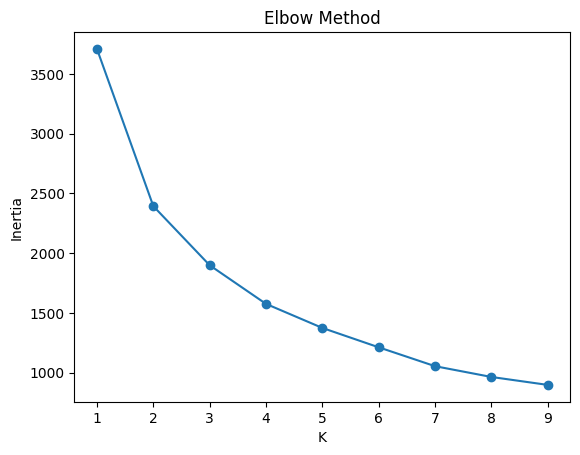

In [ ]:
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [ ]:
# For K = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
labels_4 = kmeans_4.fit_predict(X_scaled)

In [ ]:
print("K=4:", silhouette_score(X_scaled, labels_4))

K=4: 0.2573477009034391


In [ ]:
# For K = 4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.predict(X_scaled)

# Save the clustering artifacts
import pickle
pickle.dump(kmeans, open('kmeans.pkl', 'wb'))
pickle.dump(cluster_scaler, open('cluster_scaler.pkl', 'wb'))
pickle.dump(features_cluster1, open('cluster_features.pkl', 'wb'))

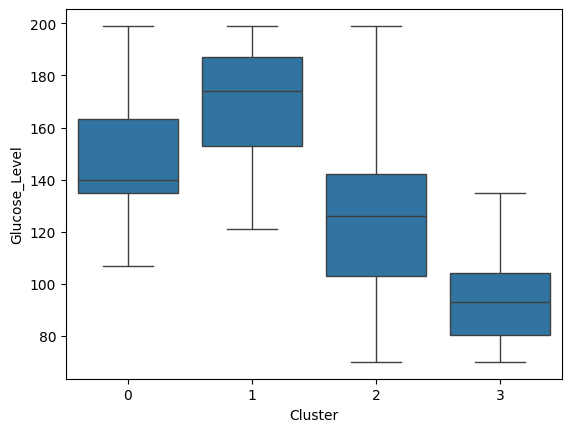

In [ ]:
sns.boxplot(x='Cluster', y='Glucose_Level', data=df)
plt.show()

In [ ]:
from sklearn.decomposition import PCA

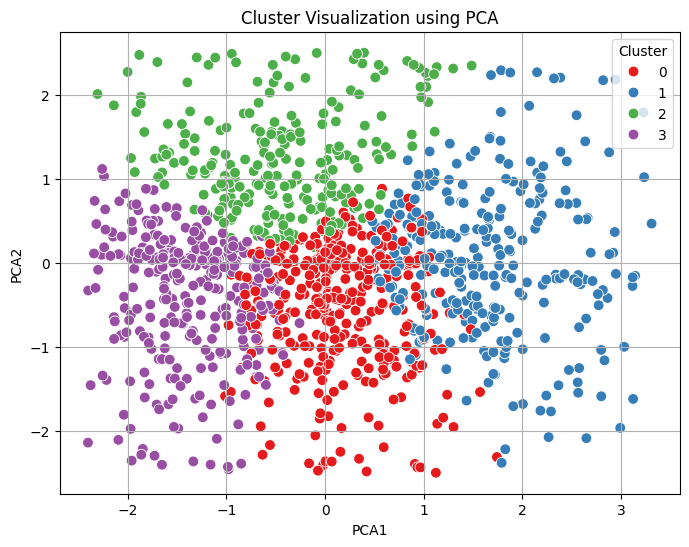

In [ ]:
# ================== PCA ==================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA columns
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# ================== PLOT ==================
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=60
)

plt.title("Cluster Visualization using PCA")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
df['Cluster'] = agg.fit_predict(X_scaled)

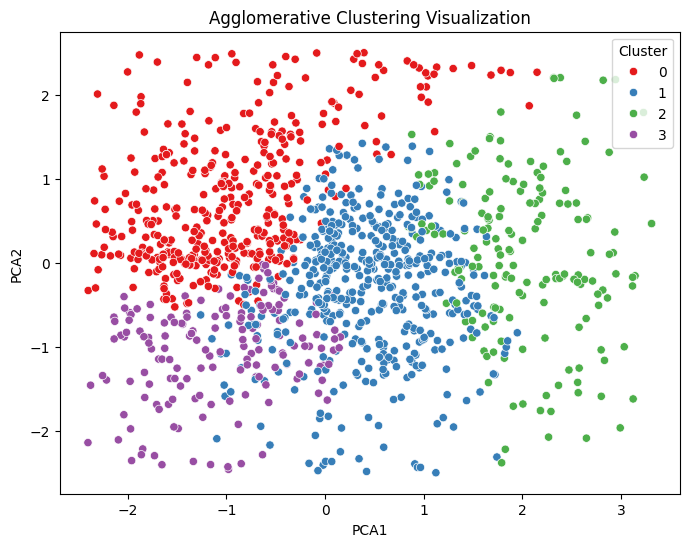

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

agg = AgglomerativeClustering(n_clusters=4)
df['Cluster'] = agg.fit_predict(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(x='PCA1', y='PCA2',
                hue='Cluster', data=df,
                palette='Set1')

plt.title("Agglomerative Clustering Visualization")
plt.show()

In [ ]:
print(df.groupby('Cluster')[['Glucose_Level','BMI','Age_Glucose']].mean())

         Glucose_Level        BMI   Age_Glucose
Cluster                                        
0           110.167476  29.135680   4715.614078
1           151.357438  24.045455   7622.752066
2           178.835227  26.696591  12596.610085
3            99.378049  20.204878   5641.719512


In [ ]:
df['Cluster_Label'] = df['Cluster'].map({
    0: 'BMI Risk',
    1: 'High Risk',
    2: 'Glucose Risk',
    3: 'Low Risk'
})

In [ ]:
df['Cluster_Label'].nunique()

4

In [ ]:
pd.crosstab(df['Cluster_Label'], df['Risk_Category'])

Risk_Category,0,1,2
Cluster_Label,,,
BMI Risk,149,148,115
Glucose Risk,6,47,123
High Risk,144,176,164
Low Risk,113,41,10


How many data points from each risk category fall into each cluster

In [ ]:
# print(X_columns)

### code

In [ ]:
import pandas as pd
import pickle

# ---------------- LOAD ----------------
lr = pickle.load(open('model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

kmeans = pickle.load(open('kmeans.pkl', 'rb'))
cluster_scaler = pickle.load(open('cluster_scaler.pkl', 'rb'))

with open('X_columns.pkl', 'rb') as f:
    X_columns = pickle.load(f)

with open('cluster_features.pkl', 'rb') as f:
    cluster_features = pickle.load(f)

# ---------------- USER INPUT ----------------
age = float(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
bp = float(input("Enter Blood Pressure: "))
chol = float(input("Enter Cholesterol: "))
gluc = float(input("Enter Glucose: "))

# ---------------- CREATE FULL INPUT ----------------
final_input = pd.DataFrame(0, index=[0], columns=X_columns)

user_dict = {
    'Age': age,
    'BMI': bmi,
    'Blood_Pressure': bp,
    'Cholesterol_Level': chol,
    'Glucose_Level': gluc
}

for col in user_dict:
    if col in final_input.columns:
        final_input[col] = user_dict[col]

# ---------------- FEATURE ENGINEERING ----------------
if 'Age_Glucose' in final_input.columns:
    final_input['Age_Glucose'] = final_input['Age'] * final_input['Glucose_Level']

if 'BP_Chol_Risk' in final_input.columns:
    final_input['BP_Chol_Risk'] = final_input['Blood_Pressure'] * final_input['Cholesterol_Level']

# Ensure correct order
final_input = final_input[X_columns]

# ---------------- SCALE ----------------
final_scaled = scaler.transform(final_input)

# ---------------- PREDICT ----------------
prediction = lr.predict(final_scaled)[0]

# ================= CLUSTER PART (FIXED) =================

# Create cluster input using SAME FEATURES as training
cluster_input = pd.DataFrame([{
    'Glucose_Level': gluc,
    'BMI': bmi,
    'Age_Glucose': age * gluc
}])

# Ensure order
cluster_input = cluster_input[cluster_features]

# Scale using CLUSTER SCALER
cluster_scaled = cluster_scaler.transform(cluster_input)

cluster = kmeans.predict(cluster_scaled)[0]

# ---------------- LABEL ----------------
cluster_labels = {
    0: 'Critical Risk',
    1: 'High Glucose Pattern',
    2: 'Obesity Pattern',
    3: 'Low Risk Lifestyle'
}

cluster_name = cluster_labels.get(cluster, "Unknown")

# ---------------- OUTPUT ----------------
print("\n🩺 Predicted Risk Score:", round(prediction, 2))

if prediction < 0.3:
    print("Risk Level: Low")
elif prediction < 0.6:
    print("Risk Level: Medium")
else:
    print("Risk Level: High")

print("\n👥 Patient Cluster:", cluster)
print("Cluster Type:", cluster_name)

Enter Age: 25
Enter BMI: 20
Enter Blood Pressure: 120
Enter Cholesterol: 180
Enter Glucose: 100

🩺 Predicted Risk Score: 0.23
Risk Level: Low

👥 Patient Cluster: 3
Cluster Type: Low Risk Lifestyle


# appp

project/
│
├── app.py
├── model.pkl
├── scaler.pkl
├── kmeans.pkl
├── cluster_scaler.pkl
├── X_columns.pkl
├── cluster_features.pkl
├── requirements.txt

In [ ]:
! pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 54.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Visualization

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------- PAGE CONFIG --------------------

st.set_page_config(page_title="Disease Risk Prediction", layout="wide")

# -------------------- LOAD FILES --------------------

lr = pickle.load(open('model.pkl', 'rb'))
kmeans = pickle.load(open('kmeans.pkl', 'rb'))

scaler = pickle.load(open('scaler.pkl', 'rb'))
cluster_scaler = pickle.load(open('cluster_scaler.pkl', 'rb'))

X_columns = pickle.load(open('X_columns.pkl', 'rb'))
cluster_features = pickle.load(open('cluster_features.pkl', 'rb'))

df = pd.read_csv("/content/clean_healthcare_data.csv")

# -------------------- SIDEBAR --------------------

st.sidebar.title("🧠 Healthcare AI System")
menu = st.sidebar.radio("Navigation", ["🏠 Prediction", "📊 EDA", "📈 Model Performance"])

# =====================================================

# 🏠 PREDICTION PAGE

# =====================================================

if menu == "🏠 Prediction":

  st.title("🩺 Disease Risk Prediction")

  col1, col2 = st.columns(2)

  with col1:
      age = st.number_input("Age", min_value=0, step=1)
      # age = st.number_input("Age", min_value=0.0)
      bmi = st.number_input("BMI")
      bp = st.number_input("Blood Pressure")

  with col2:
      chol = st.number_input("Cholesterol Level")
      gluc = st.number_input("Glucose Level")

  if st.button("Predict"):

      # ---------------- FULL INPUT ----------------
      final_input = pd.DataFrame(0, index=[0], columns=X_columns)

      user_dict = {
          'Age': age,
          'BMI': bmi,
          'Blood_Pressure': bp,
          'Cholesterol_Level': chol,
          'Glucose_Level': gluc
      }

      for col in user_dict:
          if col in final_input.columns:
              final_input[col] = user_dict[col]

      # ---------------- FEATURE ENGINEERING ----------------
      if 'Age_Glucose' in final_input.columns:
          final_input['Age_Glucose'] = final_input['Age'] * final_input['Glucose_Level']

      if 'BP_Chol_Risk' in final_input.columns:
          final_input['BP_Chol_Risk'] = final_input['Blood_Pressure'] * final_input['Cholesterol_Level']

      # Ensure correct order
      final_input = final_input[X_columns]

      # ---------------- SCALE + PREDICT ----------------
      final_scaled = scaler.transform(final_input)
      risk = lr.predict(final_scaled)[0]

      # ---------------- RISK LEVEL ----------------
      # if risk < 0.3:
      #     level = "🟢 Low"
      # elif risk < 0.6:
      #     level = "🟡 Medium"
      # else:
      #     level = "🔴 High"

      # ================= CLUSTER =================
      cluster_input = pd.DataFrame([{
          'Glucose_Level': gluc,
          'BMI': bmi,
          'Age_Glucose': age * gluc
      }])

      cluster_input = cluster_input[cluster_features]
      cluster_scaled = cluster_scaler.transform(cluster_input)
      cluster = kmeans.predict(cluster_scaled)[0]

      # ---------------- CLUSTER LABEL ----------------
      cluster_labels = {
          0: 'Critical Risk',
          1: 'High Glucose Pattern',
          2: 'Obesity Pattern',
          3: 'Low Risk Lifestyle'
      }

      cluster_name = cluster_labels.get(cluster, "Unknown")

      # ---------------- OUTPUT ----------------
      st.subheader("📌 Results")

      colA, colB, colC = st.columns(3)

      colA.metric("Risk Score", round(risk, 3))
      # colB.metric("Risk Level", level)
      colB.metric("Cluster", int(cluster))
      colC.markdown(f"### 🧬 Cluster Type: **{cluster_name}**")
      # colC.markdown("Cluster Type", cluster_name)

      # ⭐ Cluster Type Display
      # st.markdown(f"### 🧬 Cluster Type: **{cluster_name}**")

      # ---------------- PROGRESS BAR ----------------
      st.progress(float(risk))

      # ---------------- USER VISUAL ----------------
      st.subheader("📊 Your Health Overview")
      col1, col2, col3 = st.columns([1,2,1])

      with col2:
          fig, ax = plt.subplots(figsize=(6, 6))

          pd.DataFrame(user_dict, index=["You"]).T.plot(kind='bar', ax=ax, legend=False)

          plt.xticks(rotation=45)
          plt.tight_layout()

          st.pyplot(fig)

# =====================================================

# 📊 EDA PAGE

# =====================================================

elif menu == "📊 EDA":

  st.title("📊 Exploratory Data Analysis")

  st.subheader("Dataset Preview")
  st.dataframe(df.head())

  st.subheader("📉 Data Distribution")
  numeric_cols = df.select_dtypes(include=['number']).columns

  for i in range(0, len(numeric_cols), 2):
      cols = st.columns(2)

      for j in range(2):
          if i + j < len(numeric_cols):
              col_name = numeric_cols[i + j]

              with cols[j]:
                  fig, ax = plt.subplots(figsize=(5, 4))

                  sns.histplot(df[col_name], kde=True, ax=ax)

                  # ---------------- SKEWNESS ----------------
                  skew_val = df[col_name].skew()

                  if skew_val > 0.5:
                      skew_type = "Right Skewed"
                  elif skew_val < -0.5:
                      skew_type = "Left Skewed"
                  else:
                      skew_type = "Approximately Symmetric"

                  # Title with skew info
                  ax.set_title(f"{col_name}\nSkew: {round(skew_val,2)} ({skew_type})")

                  st.pyplot(fig)

  st.subheader("📦 Outlier Detection")

  num_out = [
    'Age', 'BMI', 'Blood_Pressure',
    'Cholesterol_Level', 'Glucose_Level',
    'Age_Glucose', 'BP_Chol_Risk'
      ]

  for i in range(0, len(num_out), 2):  # 2 per row
      cols = st.columns(2)

      for j in range(2):
          if i + j < len(num_out):
              col_name = num_out[i + j]

              with cols[j]:
                  fig, ax = plt.subplots(figsize=(5, 4))

                  sns.boxplot(y=df[col_name], ax=ax)

                  ax.set_title(col_name.replace("_", " "))

                  st.pyplot(fig)

# =====================================================

# 📈 MODEL PERFORMANCE

# =====================================================

elif menu == "📈 Model Performance":

    st.title("📈 Model Performance")

    # ---------------- LOAD DATA ----------------
    raw_df = pd.read_csv("/content/clean_healthcare_data.csv")

    # ---------------- TARGET ----------------
    y_actual = raw_df['Disease_Risk_Score']

    # ---------------- FEATURE DATA ----------------
    df_model = raw_df.copy()

    # Feature engineering
    df_model['Age_Glucose'] = df_model['Age'] * df_model['Glucose_Level']
    df_model['BP_Chol_Risk'] = df_model['Blood_Pressure'] * df_model['Cholesterol_Level']

    # Encoding
    df_model = pd.get_dummies(df_model)

    # Add missing columns
    for col in X_columns:
        if col not in df_model.columns:
            df_model[col] = 0

    # Ensure correct order
    df_model = df_model[X_columns]
    df_model = df_model.fillna(0)

    # ---------------- SCALE + PREDICT ----------------
    X_scaled = scaler.transform(df_model)
    y_pred = lr.predict(X_scaled)

    # ---------------- REMOVE NaN ----------------
    mask = y_actual.notna()
    y_actual = y_actual[mask]
    y_pred = y_pred[mask]

    # ---------------- SELECT X AXIS ----------------
    x = raw_df.loc[mask, 'Glucose_Level']

    # ---------------- BEST FIT LINE ----------------
    m, b = np.polyfit(x, y_pred, 1)

    # Sort for smooth line
    sorted_idx = np.argsort(x)
    x_sorted = x.iloc[sorted_idx]
    y_line = m * x_sorted + b

    # ---------------- PLOT ----------------
    col1, col2, col3 = st.columns([1, 2, 1])  # middle column bigger

    with col2:
        fig, ax = plt.subplots(figsize=(7, 5))

        # Actual (blue)
        ax.scatter(x, y_actual, label="Actual Risk", alpha=0.6)

        # Predicted (green)
        ax.scatter(x, y_pred, label="Predicted Risk", alpha=0.6)

        # Best fit (red)
        ax.plot(x_sorted, y_line, linewidth=2, label="Best Fit Line")

        ax.set_xlabel("Glucose Level")
        ax.set_ylabel("Disease Risk Score")
        ax.set_title("Glucose vs Disease Risk Score")

        ax.legend()

        st.pyplot(fig)

    # ---------------- METRICS ----------------
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

    st.write("MAE:", round(mae, 4))
    st.write("RMSE:", round(rmse, 4))

Overwriting app.py


## run code

In [ ]:
# run only once
! streamlit run app.py &>/content/logs.txt &

In [ ]:
!ngrok config add-authtoken 3CQFnZu4NNyehYV7S9aHRU5ExYo_87d17QgFnARf4ciVPV5cB

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
public_url=ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://unhappily-overthrow-immortal.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
ngrok.kill()